# Cervical Cancer Risk Factors – Mid-Term ML Project

**Dataset:** UCI Cervical Cancer (Risk Factors) — Hospital Universitario de Caracas  
**Task:** Binary classification — predict whether a patient has **cervical cancer** (Biopsy result: 0 = Negative, 1 = Positive)  
**Students:** Miled issa - Jad Maalouf - Edmond Ibllawi  
**Course:** CSIS 260
**Date:** April 2026

---

## Project Structure

| Section | Description |
|---------|-------------|
| 1 | Setup & Data Acquisition |
| 2 | Data Cleaning & Preparation |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Preprocessing & Scaling |
| 5 | Model Selection & Training |
| 6 | Model Evaluation & Comparison |
| 7 | L1 vs L2 Regularization Analysis |
| 8 | Summary & Observations |


## 1. Setup & Data Acquisition

**Goal of this section:** import all required libraries and load the Cervical Cancer dataset.

**Dataset facts:**
- **858 patients**, **36 features**, collected at Hospital Universitario de Caracas, Venezuela
- Features include demographics, sexual history, smoking habits, hormonal contraceptive use, IUD use, and STD history
- Target variable: **Biopsy** — the gold-standard diagnostic test (0 = Negative, 1 = Cancer Positive)
- The dataset contains **`?`-encoded missing values** that must be handled explicitly


In [1]:
# 1.1 Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection  import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing    import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import SVC
from sklearn.ensemble         import RandomForestClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.utils            import resample
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                       f1_score, confusion_matrix, classification_report,
                                       roc_auc_score, roc_curve, precision_recall_curve,
                                       average_precision_score)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


### 1.2 Load the dataset

**What we do here:**
- Load the CSV file using `pandas`, replacing `?` with `NaN` so Python recognises them as missing values.
- Display shape, column types, and a preview of the first rows.

In [2]:
# Load dataset — replace '?' with NaN (real missing values)
data = pd.read_csv("risk_factors_cervical_cancer.csv", na_values="?")

print(f"Shape: {data.shape[0]} rows × {data.shape[1]} columns")
print(f"\nColumn names:")
for col in data.columns:
    print(f"  • {col}")

Shape: 858 rows × 36 columns

Column names:
  • Age
  • Number of sexual partners
  • First sexual intercourse
  • Num of pregnancies
  • Smokes
  • Smokes (years)
  • Smokes (packs/year)
  • Hormonal Contraceptives
  • Hormonal Contraceptives (years)
  • IUD
  • IUD (years)
  • STDs
  • STDs (number)
  • STDs:condylomatosis
  • STDs:cervical condylomatosis
  • STDs:vaginal condylomatosis
  • STDs:vulvo-perineal condylomatosis
  • STDs:syphilis
  • STDs:pelvic inflammatory disease
  • STDs:genital herpes
  • STDs:molluscum contagiosum
  • STDs:AIDS
  • STDs:HIV
  • STDs:Hepatitis B
  • STDs:HPV
  • STDs: Number of diagnosis
  • STDs: Time since first diagnosis
  • STDs: Time since last diagnosis
  • Dx:Cancer
  • Dx:CIN
  • Dx:HPV
  • Dx
  • Hinselmann
  • Schiller
  • Citology
  • Biopsy


### 1.3 Initial dataset inspection

**What we do here:**
- Inspect data types and non-null counts.
- Check for missing values per column.
- Look at basic statistical summaries.
- Check for duplicate rows.

In [3]:
# Info about columns and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [4]:
# Missing values per column
data.isna().sum()

,0
Age,0
Number of sexual partners,26
First sexual intercourse,7
Num of pregnancies,56
Smokes,13
Smokes (years),13
Smokes (packs/year),13
Hormonal Contraceptives,108
Hormonal Contraceptives (years),108
IUD,117


In [5]:
# Statistical summary of numerical features
data.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Age,858.0,26.821,8.498,13.0,20.0,25.0,32.0,84.0
Number of sexual partners,832.0,2.528,1.668,1.0,2.0,2.0,3.0,28.0
First sexual intercourse,851.0,16.995,2.803,10.0,15.0,17.0,18.0,32.0
Num of pregnancies,802.0,2.276,1.447,0.0,1.0,2.0,3.0,11.0
Smokes,845.0,0.146,0.353,0.0,0.0,0.0,0.0,1.0
Smokes (years),845.0,1.220,4.089,0.0,0.0,0.0,0.0,37.0
Smokes (packs/year),845.0,0.453,2.227,0.0,0.0,0.0,0.0,37.0
Hormonal Contraceptives,750.0,0.641,0.480,0.0,0.0,1.0,1.0,1.0
Hormonal Contraceptives (years),750.0,2.256,3.764,0.0,0.0,0.5,3.0,30.0
IUD,741.0,0.112,0.316,0.0,0.0,0.0,0.0,1.0


In [6]:
# Duplicate rows
dup = data.duplicated().sum()
print(f"Number of duplicate rows: {dup}")

Number of duplicate rows: 23


**Observations:**
- The dataset has **858 rows and 36 columns**.
- All feature columns are numeric; `Biopsy` is the binary target.
- **26 features have missing values** encoded as `?`. The two time-since-diagnosis features are missing in **>91%** of rows.
- **23 duplicate rows** were found.
- Class imbalance is severe: **803 Negative (93.6%)** vs **55 Positive (6.4%)** — a **14.6:1 ratio**.


## 2. Data Cleaning & Preparation

**Goal of this section:** clean the dataset, handle missing values, remove irrelevant or leaky columns, and prepare the target variable.

**Steps:**
- Drop the two columns with >80% missing data (they would introduce noise, not signal).
- Remove three diagnostic-test columns (`Hinselmann`, `Schiller`, `Citology`) that constitute **target leakage** — they are other clinical tests, not risk factors.
- Audit and report remaining missing values.
- Display the final class balance.


In [7]:
# Drop columns with >80% missing data
HIGH_MISS = ["STDs: Time since first diagnosis", "STDs: Time since last diagnosis"]
data.drop(columns=HIGH_MISS, inplace=True)
print(f"Dropped high-miss columns: {HIGH_MISS}")

# Drop leaky diagnostic test columns
LEAKY = ["Hinselmann", "Schiller", "Citology"]
data.drop(columns=LEAKY, inplace=True)
print(f"Dropped leaky columns: {LEAKY}")

print(f"\nDataset shape after cleaning: {data.shape}")

Dropped high-miss columns: ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']
Dropped leaky columns: ['Hinselmann', 'Schiller', 'Citology']

Dataset shape after cleaning: (858, 31)


In [8]:
# Remaining missing values
miss = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)
miss_remaining = miss[miss > 0]
print(f"Features still with missing data ({len(miss_remaining)}):")
print(miss_remaining.round(2).to_string())

Features still with missing data (24):
IUD (years)                           13.64
IUD                                   13.64
Hormonal Contraceptives (years)       12.59
Hormonal Contraceptives               12.59
STDs:condylomatosis                   12.24
STDs (number)                         12.24
STDs                                  12.24
STDs:cervical condylomatosis          12.24
STDs:AIDS                             12.24
STDs:molluscum contagiosum            12.24
STDs:genital herpes                   12.24
STDs:pelvic inflammatory disease      12.24
STDs:syphilis                         12.24
STDs:vulvo-perineal condylomatosis    12.24
STDs:vaginal condylomatosis           12.24
STDs:Hepatitis B                      12.24
STDs:HPV                              12.24
STDs:HIV                              12.24
Num of pregnancies                     6.53
Number of sexual partners              3.03
Smokes                                 1.52
Smokes (years)                       

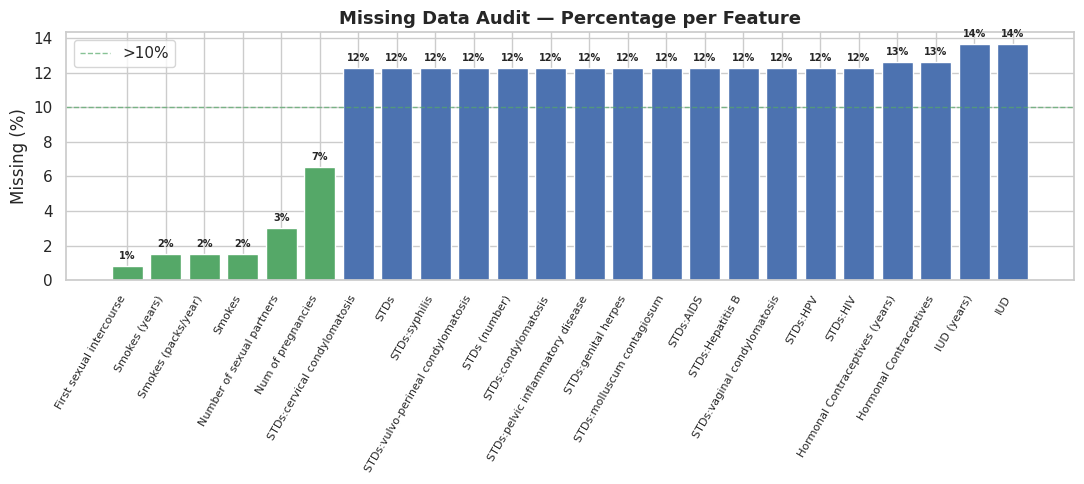

In [9]:
# Missing values visualization
miss_plot = miss[miss > 0].sort_values()
plt.figure(figsize=(11, 5))
colors = ["#C44E52" if v > 80 else "#4C72B0" if v > 10 else "#55A868" for v in miss_plot.values]
bars = plt.bar(miss_plot.index, miss_plot.values, color=colors, edgecolor="white")
plt.title("Missing Data Audit — Percentage per Feature", fontsize=13, fontweight="bold")
plt.ylabel("Missing (%)")
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.axhline(10, color="#55A868", ls="--", lw=1.0, alpha=0.7, label=">10%")
for bar, v in zip(bars, miss_plot.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.3, f"{v:.0f}%",
             ha="center", va="bottom", fontsize=7, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Class distribution table
TARGET = "Biopsy"
counts = data[TARGET].value_counts()
pct    = (data[TARGET].value_counts(normalize=True)*100).round(2)
class_summary = pd.DataFrame({"Count": counts, "Percentage (%)": pct})
class_summary.index = ["Negative (0)", "Positive (1)"]
print("Class Balance:")
print(class_summary)
print(f"\nImbalance ratio: {counts[0]/counts[1]:.1f} : 1")

Class Balance:
              Count  Percentage (%)
Negative (0)    803           93.59
Positive (1)     55            6.41

Imbalance ratio: 14.6 : 1


## 3. Exploratory Data Analysis (EDA)

**Goal of this section:** understand the data structure, identify patterns, correlations, and feature relevance.

**We will produce:**
1. Target class distribution
2. Histograms of all continuous features
3. Feature distributions split by Biopsy class (KDE overlays)
4. Boxplots by diagnosis
5. Scatter plots (Age vs risk factors)
6. Pair plots
7. Full correlation heatmap
8. Target-correlation bar charts
9. STD and binary feature prevalence by class


### 3.1 Target distribution

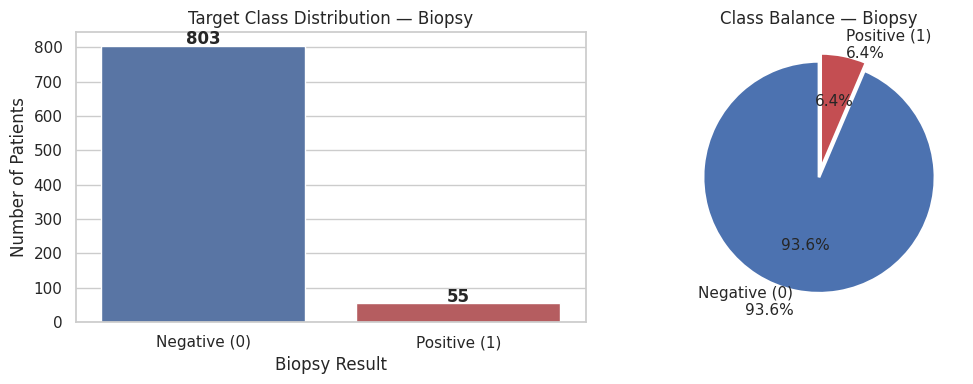

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Countplot
sns.countplot(x=TARGET, data=data, palette=["#4C72B0","#C44E52"], ax=axes[0])
axes[0].set_xticklabels(["Negative (0)", "Positive (1)"])
axes[0].set_title("Target Class Distribution — Biopsy")
axes[0].set_xlabel("Biopsy Result"); axes[0].set_ylabel("Number of Patients")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha="center", fontsize=12, fontweight="bold")

# Pie chart
counts = data[TARGET].value_counts()
axes[1].pie(counts, labels=["Negative (0)\n93.6%","Positive (1)\n6.4%"],
            colors=["#4C72B0","#C44E52"],
            explode=[0, 0.07], startangle=90,
            autopct="%1.1f%%", textprops={"fontsize": 11},
            wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Class Balance — Biopsy")
plt.tight_layout()
plt.show()

**Observation:** The dataset is **highly imbalanced** — only 6.4% of patients have a positive biopsy.  
This is clinically realistic but makes recall the primary metric of interest.  
We will apply **oversampling** on the training set to compensate.


### 3.2 Histograms of continuous features

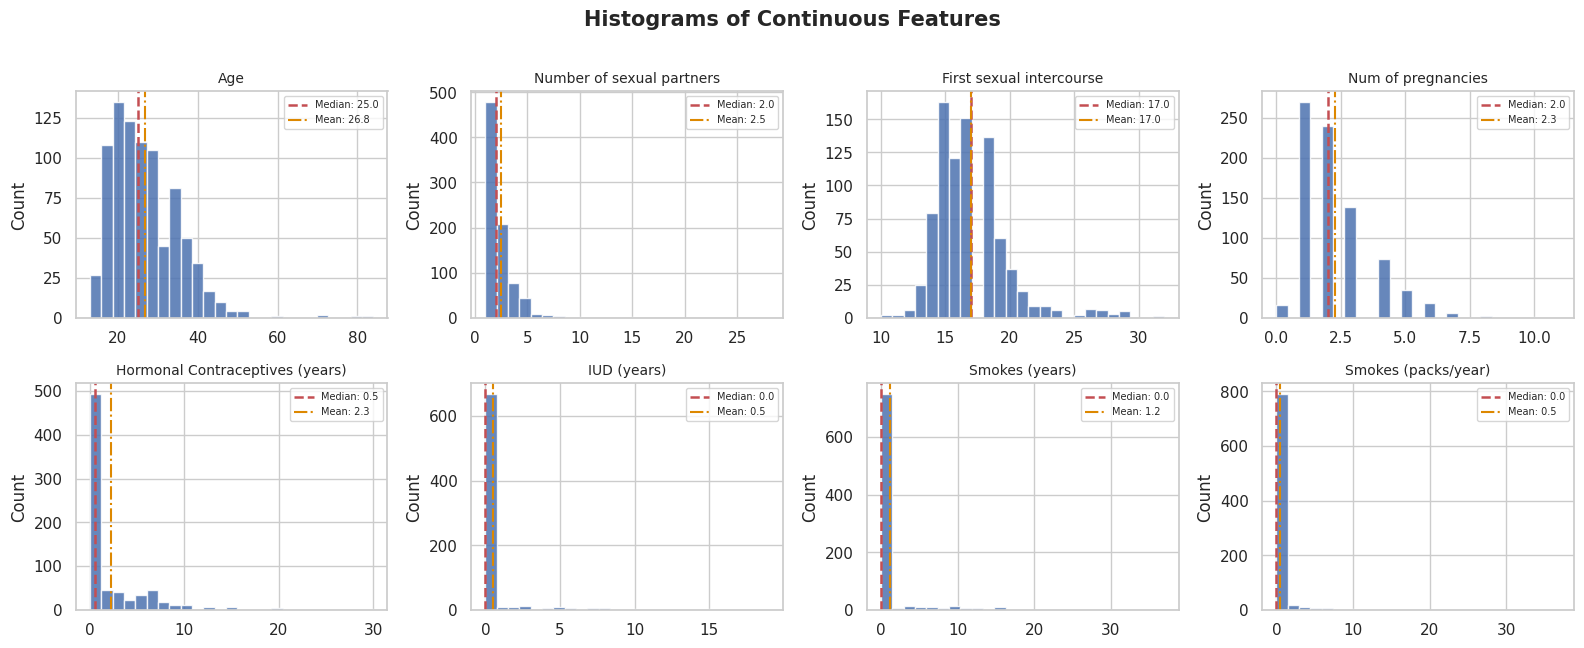

In [12]:
# Histograms — all continuous features
cont_features = ["Age", "Number of sexual partners", "First sexual intercourse",
                 "Num of pregnancies", "Hormonal Contraceptives (years)",
                 "IUD (years)", "Smokes (years)", "Smokes (packs/year)"]
cont_features = [c for c in cont_features if c in data.columns]

ncols = 4
nrows = (len(cont_features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*3.2))
axes_flat = axes.flatten()

for i, col in enumerate(cont_features):
    d = data[col].dropna()
    axes_flat[i].hist(d, bins=25, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes_flat[i].axvline(d.median(), color="#C44E52", ls="--", lw=1.8, label=f"Median: {d.median():.1f}")
    axes_flat[i].axvline(d.mean(),   color="#DD8800", ls="-.", lw=1.5, label=f"Mean: {d.mean():.1f}")
    axes_flat[i].set_title(col, fontsize=10)
    axes_flat[i].set_ylabel("Count")
    axes_flat[i].legend(fontsize=7)
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Histograms of Continuous Features", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Feature distributions by Biopsy class (KDE overlays)

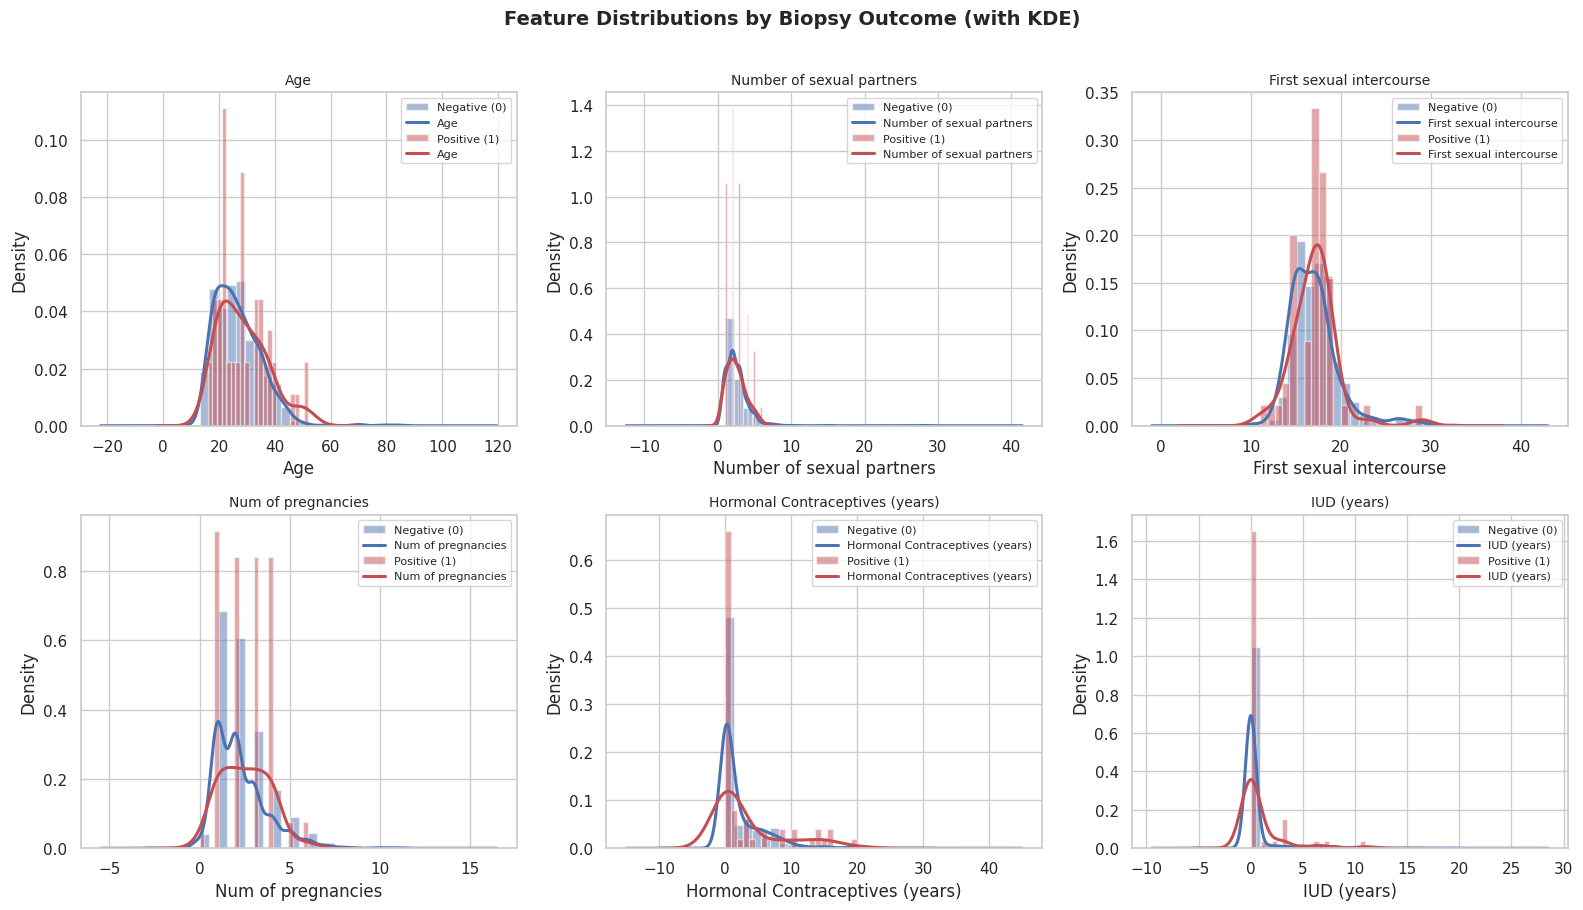

In [13]:
# Histograms split by Biopsy outcome — with KDE
plot_cols = ["Age", "Number of sexual partners", "First sexual intercourse",
             "Num of pregnancies", "Hormonal Contraceptives (years)", "IUD (years)"]
plot_cols = [c for c in plot_cols if c in data.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()
for i, col in enumerate(plot_cols):
    for bval, color, label in [(0,"#4C72B0","Negative (0)"), (1,"#C44E52","Positive (1)")]:
        subset = data[data[TARGET]==bval][col].dropna()
        axes_flat[i].hist(subset, bins=22, alpha=0.5, color=color, density=True,
                          edgecolor="white", label=label)
        subset.plot.kde(ax=axes_flat[i], color=color, linewidth=2.2)
    axes_flat[i].set_title(col, fontsize=10)
    axes_flat[i].set_xlabel(col); axes_flat[i].set_ylabel("Density")
    axes_flat[i].legend(fontsize=8)

fig.suptitle("Feature Distributions by Biopsy Outcome (with KDE)", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Boxplots by diagnosis

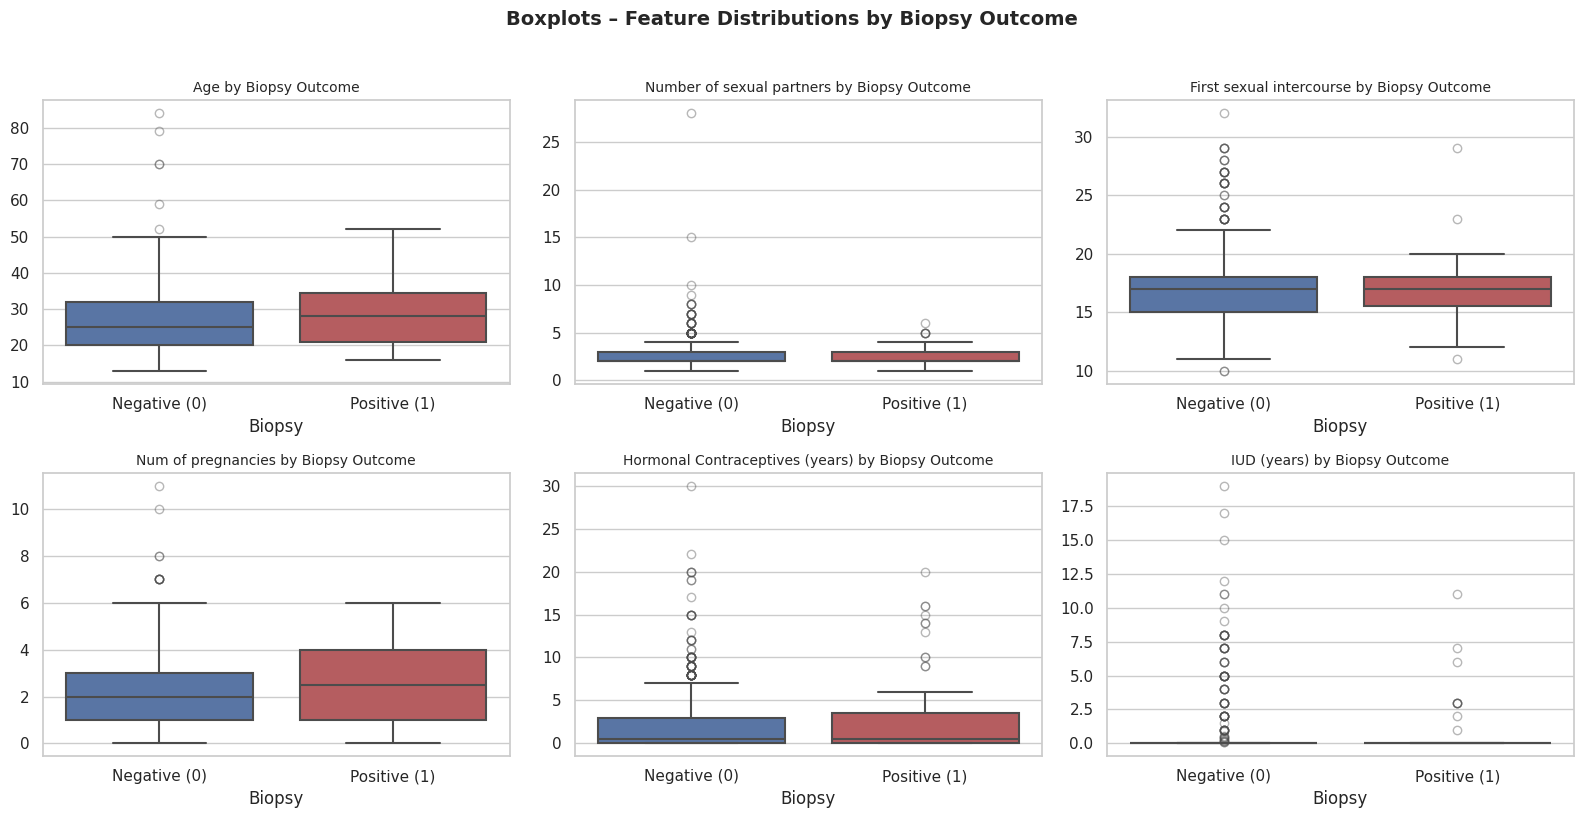

In [14]:
box_features = plot_cols.copy()

import math

n_features = len(box_features)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes_flat = axes.flatten()

for i, col in enumerate(box_features):
    sns.boxplot(
        x=TARGET,
        y=col,
        data=data,
        hue=TARGET,
        palette={0: "#4C72B0", 1: "#C44E52"},
        ax=axes_flat[i],
        linewidth=1.5,
        legend=False,
        flierprops={"alpha": 0.4}
    )
    axes_flat[i].set_xticklabels(["Negative (0)", "Positive (1)"])
    axes_flat[i].set_title(f"{col} by Biopsy Outcome", fontsize=10)
    axes_flat[i].set_xlabel("Biopsy")
    axes_flat[i].set_ylabel("")

# hide empty subplot spaces
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    "Boxplots – Feature Distributions by Biopsy Outcome",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

### 3.5 Scatter Plots — Age vs Key Risk Factors

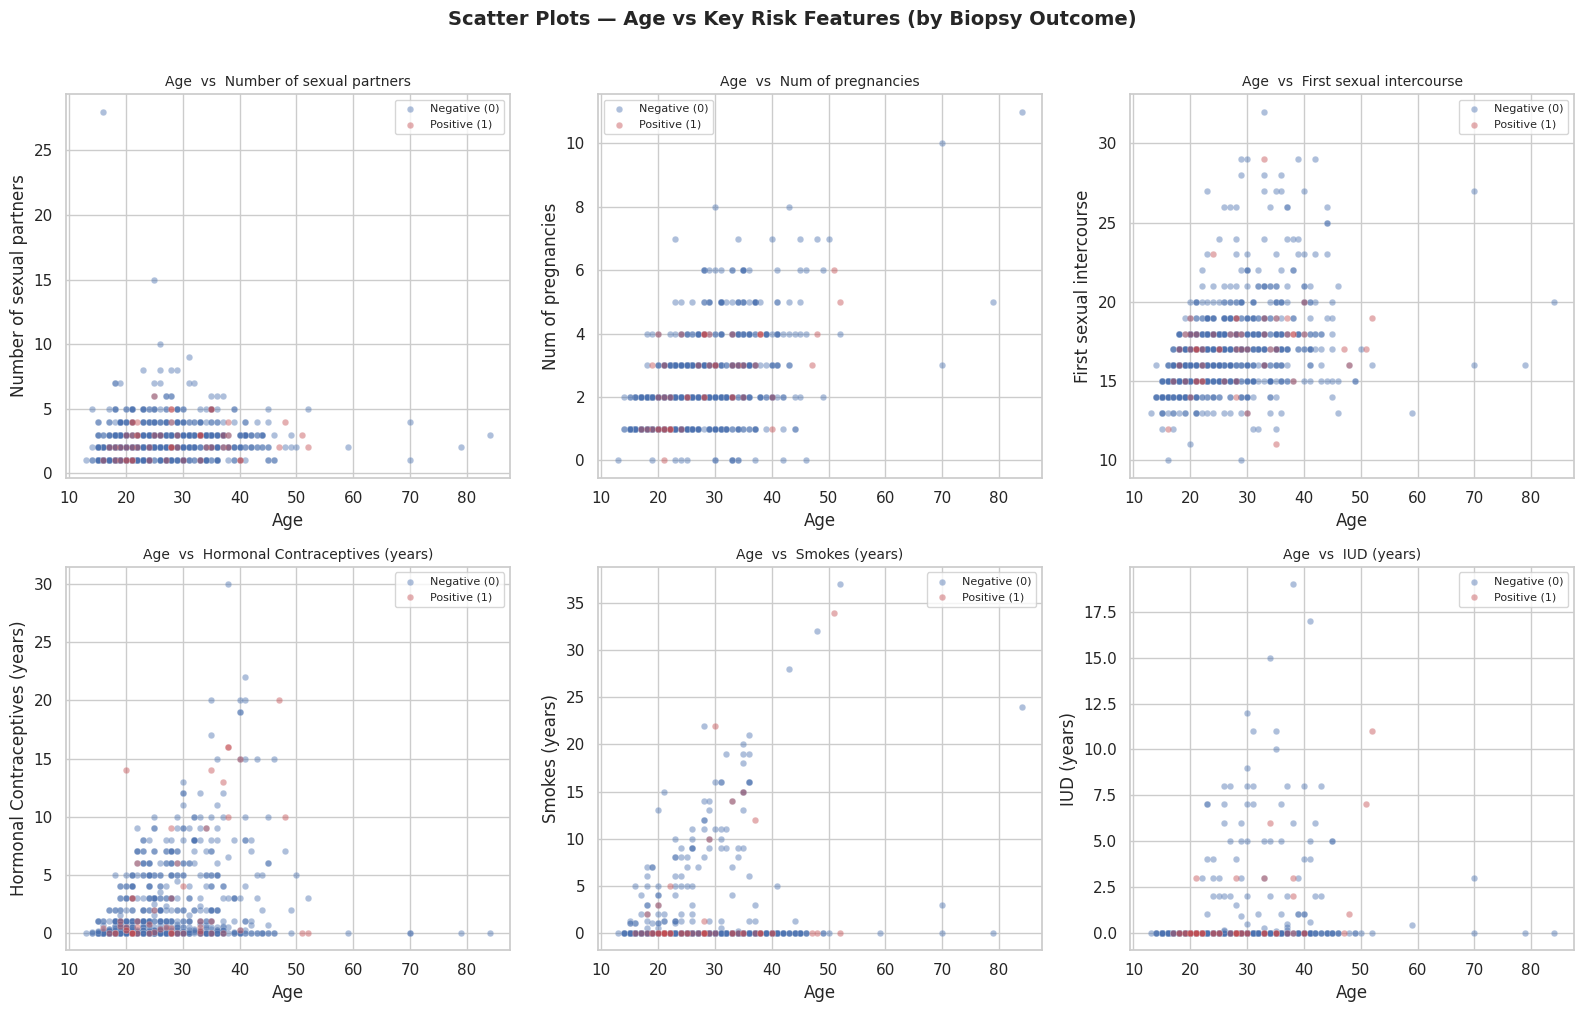

In [15]:
scatter_targets = ["Number of sexual partners", "Num of pregnancies",
                   "First sexual intercourse", "Hormonal Contraceptives (years)",
                   "Smokes (years)", "IUD (years)"]
scatter_targets = [c for c in scatter_targets if c in data.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()
for i, col in enumerate(scatter_targets):
    for bval, color, label in [(0,"#4C72B0","Negative (0)"), (1,"#C44E52","Positive (1)")]:
        subset = data[data[TARGET]==bval].dropna(subset=["Age", col])
        axes_flat[i].scatter(subset["Age"], subset[col],
                              alpha=0.45, s=22, color=color, label=label,
                              edgecolors="white", linewidths=0.2)
    axes_flat[i].set_xlabel("Age"); axes_flat[i].set_ylabel(col)
    axes_flat[i].set_title(f"Age  vs  {col}", fontsize=10)
    axes_flat[i].legend(fontsize=8)

fig.suptitle("Scatter Plots — Age vs Key Risk Features (by Biopsy Outcome)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.6 Pair Plot

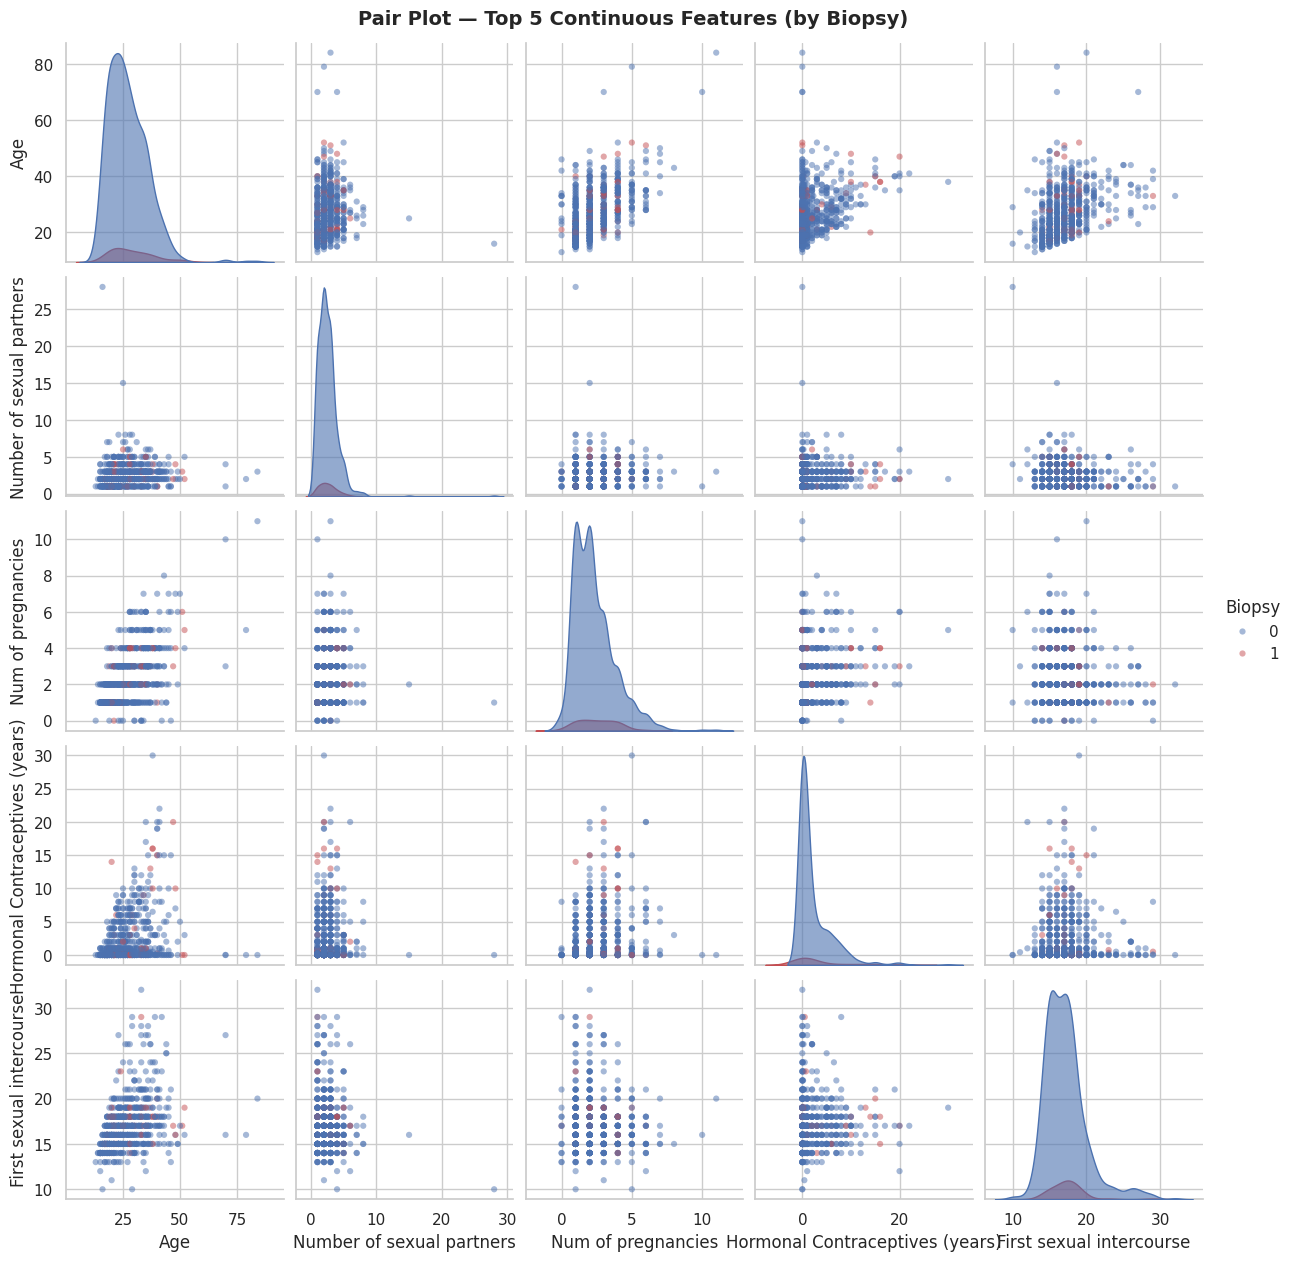

In [16]:
# Pair plot — top 5 continuous features
pair_cols = ["Age", "Number of sexual partners", "Num of pregnancies",
             "Hormonal Contraceptives (years)", "First sexual intercourse", TARGET]
pair_cols = [c for c in pair_cols if c in data.columns]

df_pair = data[pair_cols].dropna().copy()
df_pair[TARGET] = df_pair[TARGET].astype(str)

g = sns.pairplot(df_pair, hue=TARGET,
                 palette={"0":"#4C72B0","1":"#C44E52"},
                 plot_kws={"alpha":0.5,"s":20,"edgecolor":"none"},
                 diag_kws={"alpha":0.6}, corner=False)
g.figure.suptitle("Pair Plot — Top 5 Continuous Features (by Biopsy)",
                   y=1.01, fontsize=14, fontweight="bold")
plt.show()

### 3.7 Correlation Analysis

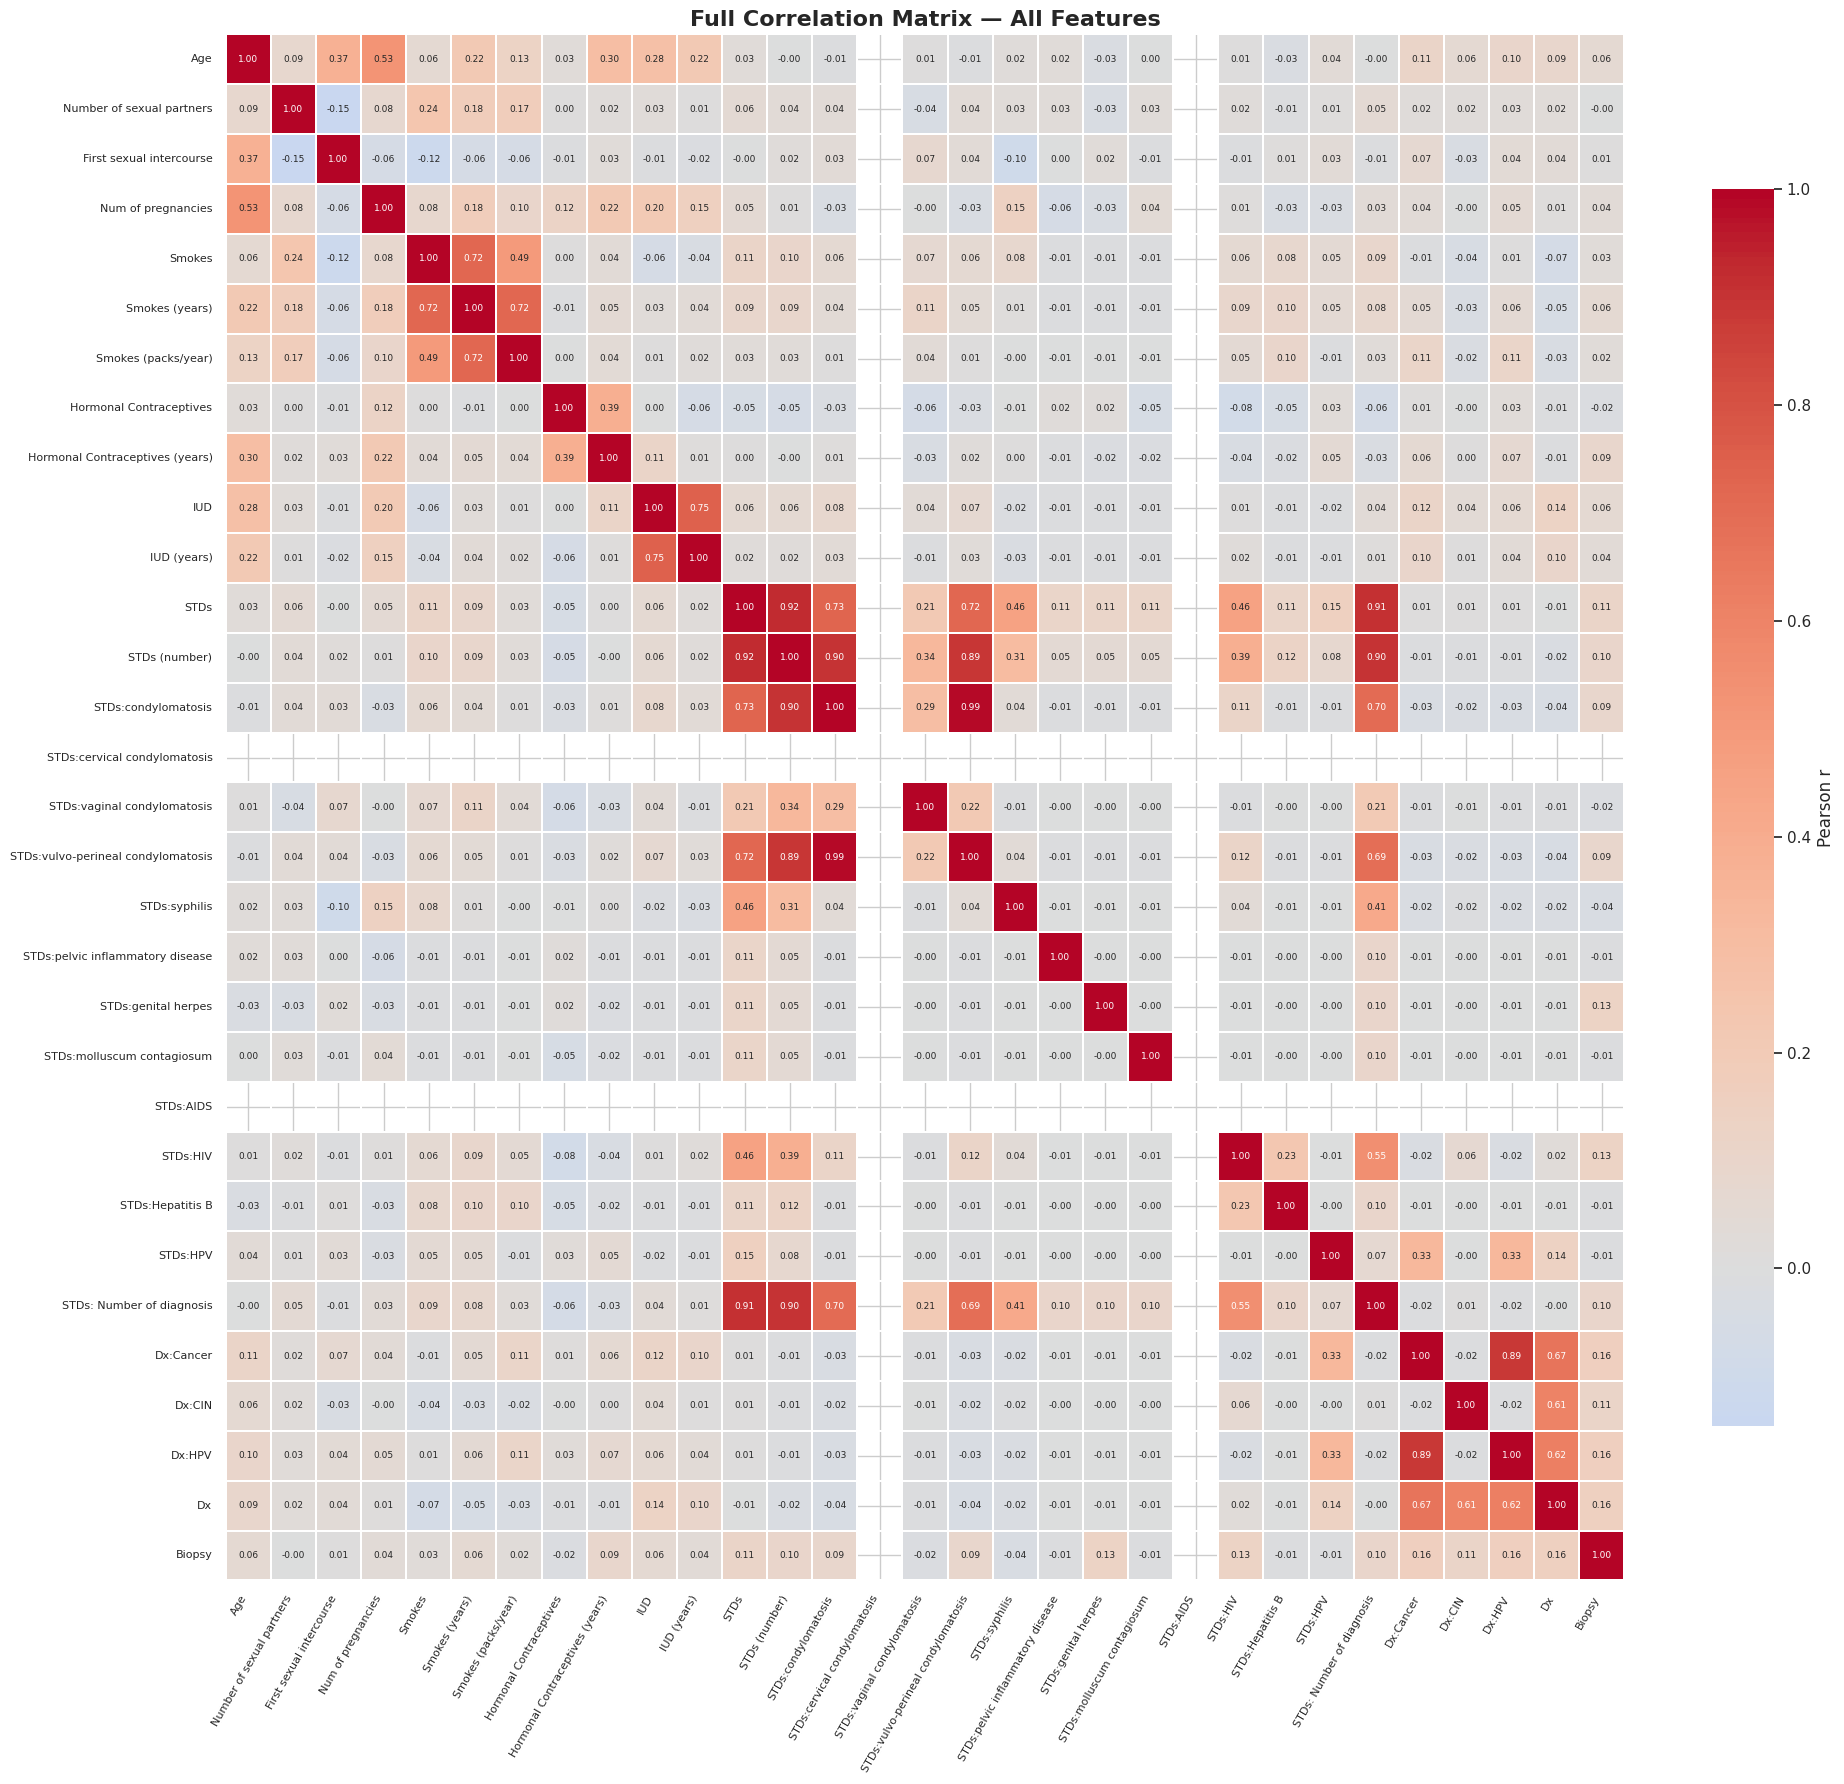

In [17]:
# Compute full correlation matrix (after median imputation)
num_df = data.select_dtypes(include=[np.number]).copy()
num_df_filled = num_df.fillna(num_df.median())
corr_matrix = num_df_filled.corr()

# Full heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0,
            linewidths=0.3, linecolor="white",
            annot=True, fmt=".2f",
            annot_kws={"size":6.5},
            cbar_kws={"shrink":0.8, "label":"Pearson r"})
plt.title("Full Correlation Matrix — All Features", fontsize=16, fontweight="bold")
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Top 10 features positively correlated with Biopsy:
Dx:Cancer                          0.1609
Dx:HPV                             0.1609
Dx                                 0.1576
STDs:genital herpes                0.1305
STDs:HIV                           0.1277
STDs                               0.1141
Dx:CIN                             0.1132
STDs (number)                      0.1032
STDs: Number of diagnosis          0.0974
Hormonal Contraceptives (years)    0.0942


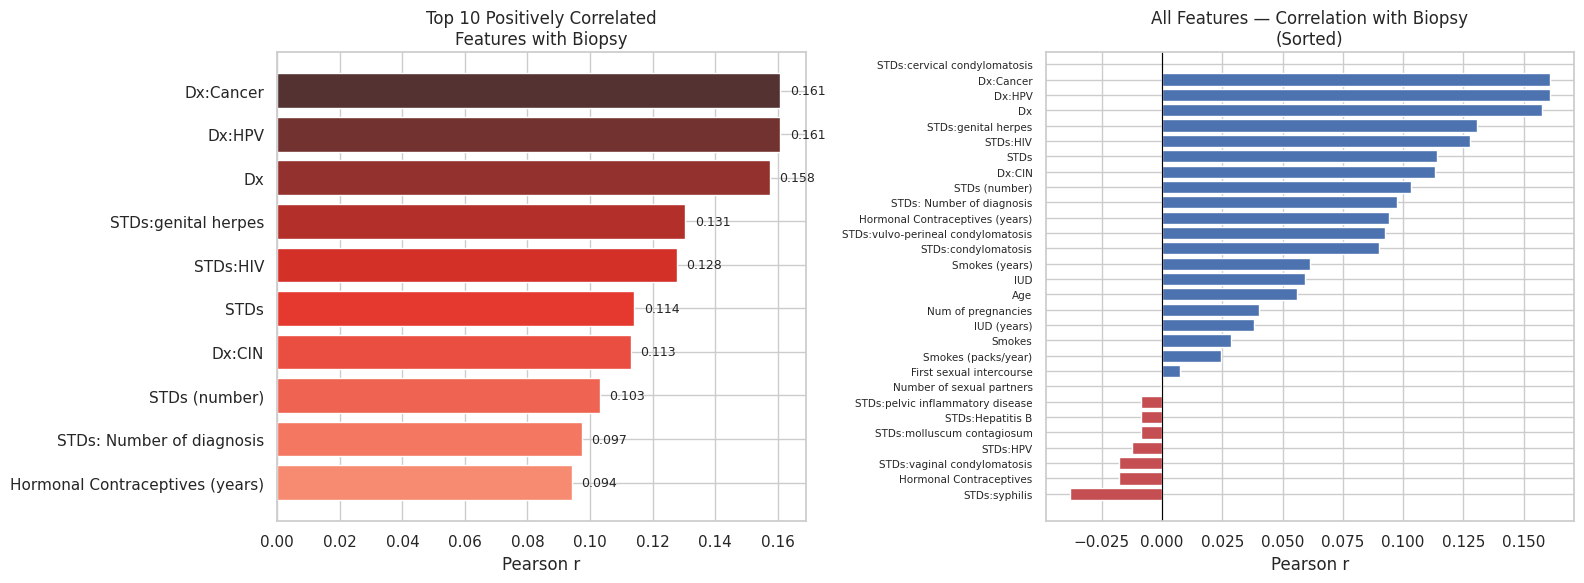

In [18]:
# Correlation with target variable
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
top10_pos = target_corr.head(10)
top10_all = target_corr.sort_values()

print("Top 10 features positively correlated with Biopsy:")
print(top10_pos.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 positive
axes[0].barh(top10_pos.index[::-1], top10_pos.values[::-1],
             color=sns.color_palette("Reds_d", 10), edgecolor="white")
axes[0].set_title("Top 10 Positively Correlated\nFeatures with Biopsy")
axes[0].set_xlabel("Pearson r")
for i, v in enumerate(top10_pos.values[::-1]):
    axes[0].text(v+0.003, i, f"{v:.3f}", va="center", fontsize=9)

# All features sorted
c_colors = ["#C44E52" if v < 0 else "#4C72B0" for v in top10_all.values]
axes[1].barh(top10_all.index, top10_all.values, color=c_colors, edgecolor="white")
axes[1].set_title("All Features — Correlation with Biopsy\n(Sorted)")
axes[1].set_xlabel("Pearson r")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].tick_params(axis="y", labelsize=7.5)
plt.tight_layout()
plt.show()

**Key Correlation Findings:**
- **`Dx:Cancer`, `Dx`, `Dx:HPV`, `Dx:CIN`** have the strongest positive correlations with Biopsy — these reflect prior cancer/HPV diagnoses, which are logically the strongest predictors.
- **`STDs:HIV`, `STDs:syphilis`** show moderate positive correlation — STD presence is a clinical risk factor.
- **`Age`** shows a small positive correlation — older age is a known epidemiological risk.
- No features show strong *negative* correlation with Biopsy.


### 3.8 Binary Features & STD Analysis

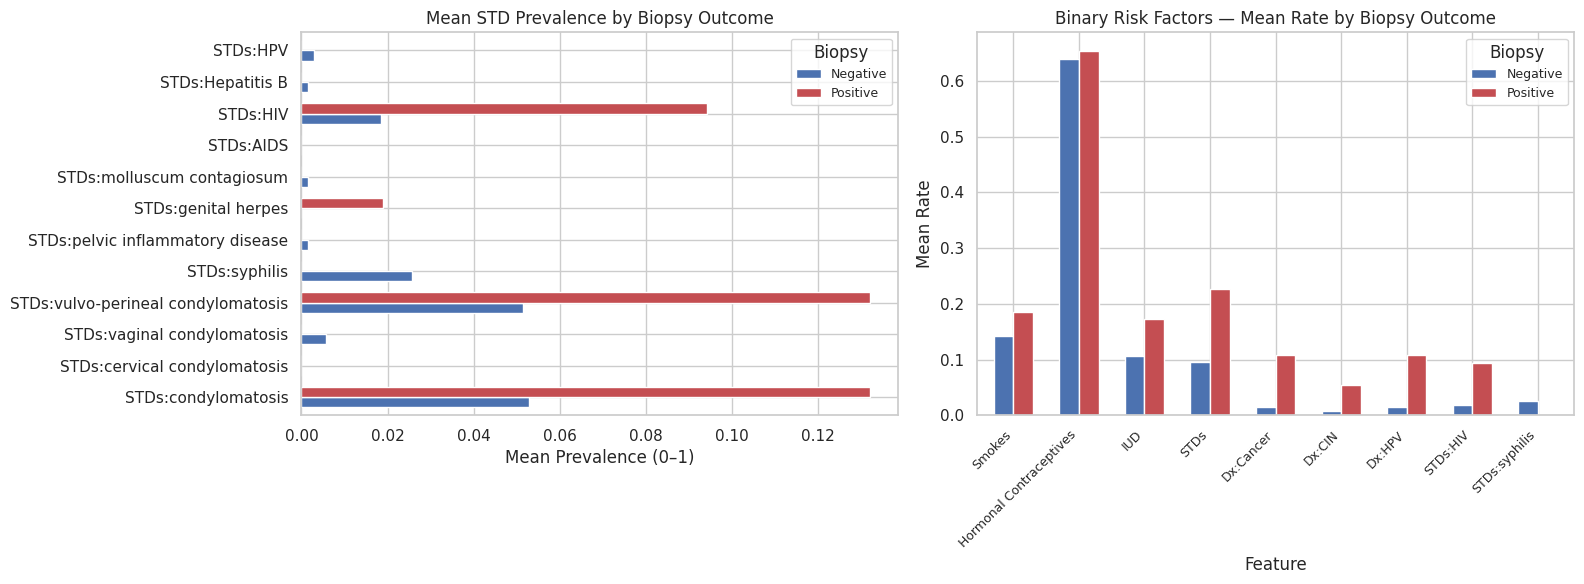

In [19]:
std_cols = [c for c in data.columns if c.startswith("STDs:") and data[c].nunique() <= 3]
std_prev = pd.DataFrame({
    col: {
        "Negative": data[data[TARGET]==0][col].mean(),
        "Positive": data[data[TARGET]==1][col].mean()
    } for col in std_cols
}).T

bin_features = ["Smokes","Hormonal Contraceptives","IUD","STDs",
                "Dx:Cancer","Dx:CIN","Dx:HPV","STDs:HIV","STDs:syphilis"]
bin_features = [c for c in bin_features if c in data.columns]
bin_prev = pd.DataFrame({
    col: {
        "Negative": data[data[TARGET]==0][col].mean(),
        "Positive": data[data[TARGET]==1][col].mean()
    } for col in bin_features
}).T

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
std_prev.plot.barh(ax=axes[0], color=["#4C72B0","#C44E52"], edgecolor="white", width=0.65)
axes[0].set_title("Mean STD Prevalence by Biopsy Outcome")
axes[0].set_xlabel("Mean Prevalence (0–1)")
axes[0].legend(title="Biopsy", fontsize=9)

bin_prev.plot.bar(ax=axes[1], color=["#4C72B0","#C44E52"], edgecolor="white", width=0.6)
axes[1].set_title("Binary Risk Factors — Mean Rate by Biopsy Outcome")
axes[1].set_xlabel("Feature"); axes[1].set_ylabel("Mean Rate")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=9)
axes[1].legend(title="Biopsy", fontsize=9)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Scaling

**Goal of this section:** prepare the data for model training.

**Steps:**
1. Separate features `X` and target `y`
2. Stratified 80/20 train–test split
3. Handle class imbalance via oversampling (minority class) on the **training set only** — the test set is untouched
4. Median imputation for remaining missing values
5. Standardise with `StandardScaler` (fit on train only, transform both)

> ⚠️ **Important:** All preprocessing is fit on training data only and then applied to the test set, to prevent **data leakage**.


In [20]:
# Separate features and target
FEATURES = [c for c in data.columns if c != TARGET]
X = data[FEATURES].copy()
y = data[TARGET].copy()

# Stratified 80/20 split
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train_raw.shape[0]} rows  —  Positive: {y_train_raw.sum():.0f} ({y_train_raw.mean()*100:.1f}%)")
print(f"Test  set: {X_test_raw.shape[0]} rows   —  Positive: {y_test.sum():.0f} ({y_test.mean()*100:.1f}%)")

Train set: 686 rows  —  Positive: 44 (6.4%)
Test  set: 172 rows   —  Positive: 11 (6.4%)


In [21]:
# Handle class imbalance — oversample minority on training set only
train_full = pd.concat([X_train_raw, y_train_raw], axis=1)
majority   = train_full[train_full[TARGET] == 0]
minority   = train_full[train_full[TARGET] == 1]

minority_upsampled = resample(minority, replace=True,
                               n_samples=len(majority), random_state=42)
train_balanced = pd.concat([majority, minority_upsampled])

X_train = train_balanced.drop(TARGET, axis=1)
y_train = train_balanced[TARGET]

print(f"Balanced train set: {len(X_train)} rows")
print(f"  Negative: {(y_train==0).sum()} ({(y_train==0).mean()*100:.0f}%)")
print(f"  Positive: {(y_train==1).sum()} ({(y_train==1).mean()*100:.0f}%)")

Balanced train set: 1284 rows
  Negative: 642 (50%)
  Positive: 642 (50%)


In [22]:
# Impute missing values (median strategy — robust to outliers)
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test_raw)

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Verify: should be ~0 mean, ~1 std
scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURES)
print("After StandardScaler — Training set statistics (first 5 features):")
print(scaled_df.describe().T.head(5)[["mean","std"]].round(4))

After StandardScaler — Training set statistics (first 5 features):
                           mean     std
Age                        -0.0  1.0004
Number of sexual partners   0.0  1.0004
First sexual intercourse   -0.0  1.0004
Num of pregnancies         -0.0  1.0004
Smokes                      0.0  1.0004


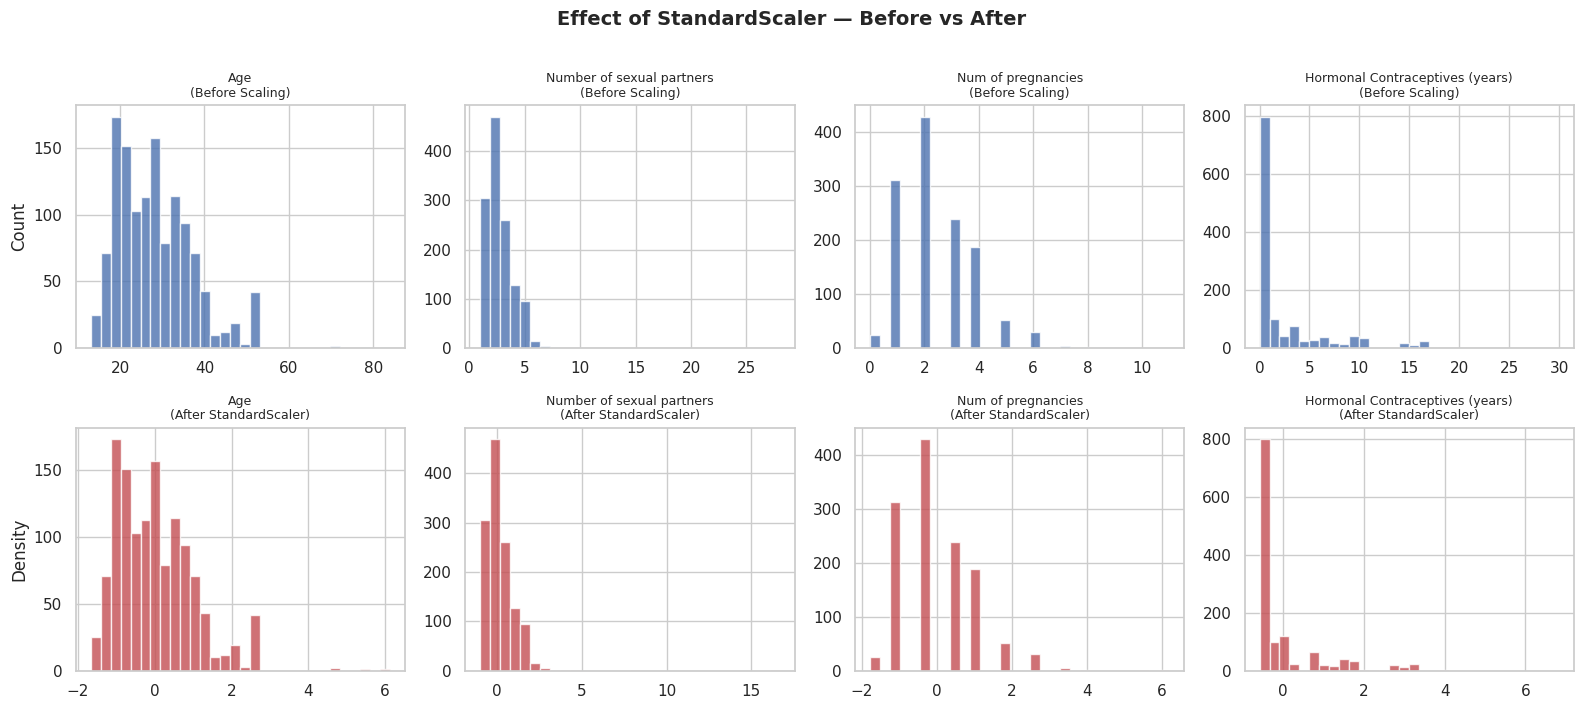

In [23]:
# Scaling effect visualization
cols_show = ["Age", "Number of sexual partners", "Num of pregnancies",
             "Hormonal Contraceptives (years)"]
col_idxs  = [FEATURES.index(c) for c in cols_show]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for j, (col, idx) in enumerate(zip(cols_show, col_idxs)):
    raw_vals = X_train_imp[:, idx]
    scl_vals = X_train_scaled[:, idx]
    axes[0][j].hist(raw_vals, bins=30, color="#4C72B0", edgecolor="white", alpha=0.8)
    axes[0][j].set_title(f"{col}\n(Before Scaling)", fontsize=9)
    axes[0][j].set_ylabel("Count" if j==0 else "")
    axes[1][j].hist(scl_vals, bins=30, color="#C44E52", edgecolor="white", alpha=0.8)
    axes[1][j].set_title(f"{col}\n(After StandardScaler)", fontsize=9)
    axes[1][j].set_ylabel("Density" if j==0 else "")
fig.suptitle("Effect of StandardScaler — Before vs After", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Model Selection and Training

**Goal of this section:** train five classification models and apply regularization.

**Chosen models:**

| Model | Regularization | Notes |
|-------|---------------|-------|
| Logistic Regression (L2) | L2 — Ridge | Baseline linear model; shrinks all coefficients |
| Logistic Regression (L1) | L1 — Lasso | Encourages sparsity; some coefficients → 0 |
| SVM (RBF kernel) | Implicit via `C` | Non-linear; strong with scaled data |
| Random Forest | Tree depth / `n_estimators` | Ensemble; robust to noise |
| Decision Tree | `max_depth` | Interpretable baseline tree |

> All models are trained on the **balanced** (oversampled) training set with **scaled** features.


### 5.1 Logistic Regression (L2 regularization)

In [24]:
log_reg_l2 = LogisticRegression(
    penalty="l2", C=1.0, solver="lbfgs",
    max_iter=2000, class_weight="balanced", random_state=42
)
log_reg_l2.fit(X_train_scaled, y_train)
print("LogReg L2 trained. Non-zero coefs:", np.sum(log_reg_l2.coef_[0] != 0))

LogReg L2 trained. Non-zero coefs: 27


### 5.2 Logistic Regression (L1 regularization)

In [25]:
log_reg_l1 = LogisticRegression(
    penalty="l1", C=0.5, solver="liblinear",
    max_iter=2000, class_weight="balanced", random_state=42
)
log_reg_l1.fit(X_train_scaled, y_train)
print("LogReg L1 trained. Non-zero coefs:", np.sum(log_reg_l1.coef_[0] != 0))

LogReg L1 trained. Non-zero coefs: 22


### 5.3 Support Vector Machine (RBF kernel)

In [26]:
svm_clf = SVC(
    kernel="rbf", C=10, gamma="scale",
    probability=True, class_weight="balanced", random_state=42
)
svm_clf.fit(X_train_scaled, y_train)
print("SVM RBF trained.")

SVM RBF trained.


### 5.4 Random Forest Classifier

In [27]:
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=3,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf_clf.fit(X_train_scaled, y_train)
print("Random Forest trained.")

Random Forest trained.


### 5.5 Decision Tree Classifier

In [28]:
dt_clf = DecisionTreeClassifier(
    max_depth=6, class_weight="balanced", random_state=42
)
dt_clf.fit(X_train_scaled, y_train)
print("Decision Tree trained.")

Decision Tree trained.


## 6. Model Evaluation and Comparison

**Goal of this section:** evaluate each model on the held-out test set using multiple metrics.

**Metrics used:**
- **Accuracy** — overall correct predictions
- **Precision** — of predicted positives, how many are truly positive
- **Recall (Sensitivity)** — of true positives, how many were found ← *most important in cancer screening*
- **F1-Score** — harmonic mean of precision and recall
- **AUC-ROC** — area under the receiver operating characteristic curve

> 🏥 **Clinical priority:** In a cancer screening context, **recall** is the most critical metric.  
> A **false negative** (missed cancer) is far more costly than a false positive.


### 6.1 Evaluation helper function

In [29]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Compute metrics, print report, and plot confusion matrix."""
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)
    y_prob_test  = model.predict_proba(X_te)[:, 1]

    metrics = {
        "Model":      name,
        "Train Acc":  accuracy_score(y_tr, y_pred_train),
        "Test Acc":   accuracy_score(y_te, y_pred_test),
        "Precision":  precision_score(y_te, y_pred_test, zero_division=0),
        "Recall":     recall_score(y_te, y_pred_test, zero_division=0),
        "F1-Score":   f1_score(y_te, y_pred_test, zero_division=0),
        "AUC-ROC":    roc_auc_score(y_te, y_prob_test),
        "y_pred": y_pred_test, "y_prob": y_prob_test,
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Train Accuracy : {metrics['Train Acc']:.4f}")
    print(f"  Test  Accuracy : {metrics['Test Acc']:.4f}")
    print(f"  Precision      : {metrics['Precision']:.4f}")
    print(f"  Recall         : {metrics['Recall']:.4f}")
    print(f"  F1-Score       : {metrics['F1-Score']:.4f}")
    print(f"  AUC-ROC        : {metrics['AUC-ROC']:.4f}")
    print(f"\nClassification Report (Test Set):")
    print(classification_report(y_te, y_pred_test,
                                 target_names=["Negative (0)", "Positive (1)"],
                                 digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred_test)
    tn, fp, fn, tp = cm.ravel()
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Neg (0)", "Pos (1)"],
                yticklabels=["Neg (0)", "Pos (1)"],
                linewidths=1, linecolor="white", cbar=False,
                annot_kws={"size": 13, "weight": "bold"})
    plt.title(f"Confusion Matrix — {name}\n"
              f"Sensitivity: {tp/(tp+fn+1e-9):.2%}   Specificity: {tn/(tn+fp+1e-9):.2%}")
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

    return metrics

print("Helper function defined.")

Helper function defined.


### 6.2 Evaluate all models


  LogReg L2
  Train Accuracy : 0.7126
  Test  Accuracy : 0.8081
  Precision      : 0.1333
  Recall         : 0.3636
  F1-Score       : 0.1951
  AUC-ROC        : 0.6369

Classification Report (Test Set):
              precision    recall  f1-score   support

Negative (0)     0.9507    0.8385    0.8911       161
Positive (1)     0.1333    0.3636    0.1951        11

    accuracy                         0.8081       172
   macro avg     0.5420    0.6011    0.5431       172
weighted avg     0.8984    0.8081    0.8466       172



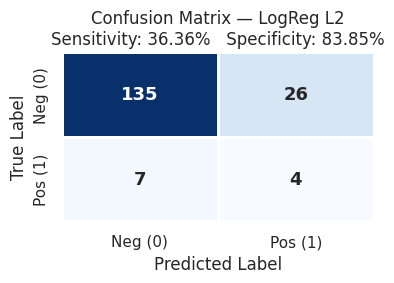


  LogReg L1
  Train Accuracy : 0.7118
  Test  Accuracy : 0.8140
  Precision      : 0.1379
  Recall         : 0.3636
  F1-Score       : 0.2000
  AUC-ROC        : 0.6392

Classification Report (Test Set):
              precision    recall  f1-score   support

Negative (0)     0.9510    0.8447    0.8947       161
Positive (1)     0.1379    0.3636    0.2000        11

    accuracy                         0.8140       172
   macro avg     0.5445    0.6042    0.5474       172
weighted avg     0.8990    0.8140    0.8503       172



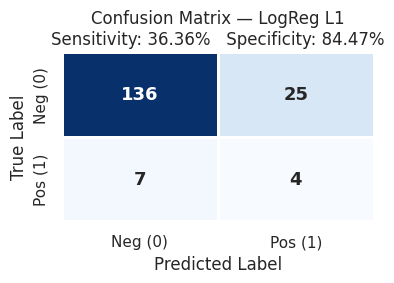


  SVM RBF
  Train Accuracy : 0.8590
  Test  Accuracy : 0.8837
  Precision      : 0.0909
  Recall         : 0.0909
  F1-Score       : 0.0909
  AUC-ROC        : 0.6025

Classification Report (Test Set):
              precision    recall  f1-score   support

Negative (0)     0.9379    0.9379    0.9379       161
Positive (1)     0.0909    0.0909    0.0909        11

    accuracy                         0.8837       172
   macro avg     0.5144    0.5144    0.5144       172
weighted avg     0.8837    0.8837    0.8837       172



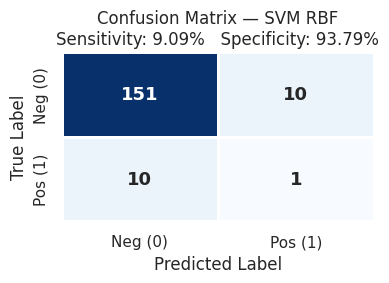


  Random Forest
  Train Accuracy : 0.8614
  Test  Accuracy : 0.8837
  Precision      : 0.0000
  Recall         : 0.0000
  F1-Score       : 0.0000
  AUC-ROC        : 0.6697

Classification Report (Test Set):
              precision    recall  f1-score   support

Negative (0)     0.9325    0.9441    0.9383       161
Positive (1)     0.0000    0.0000    0.0000        11

    accuracy                         0.8837       172
   macro avg     0.4663    0.4720    0.4691       172
weighted avg     0.8729    0.8837    0.8783       172



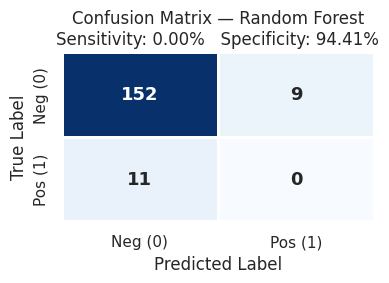


  Decision Tree
  Train Accuracy : 0.7913
  Test  Accuracy : 0.9128
  Precision      : 0.2500
  Recall         : 0.1818
  F1-Score       : 0.2105
  AUC-ROC        : 0.5762

Classification Report (Test Set):
              precision    recall  f1-score   support

Negative (0)     0.9451    0.9627    0.9538       161
Positive (1)     0.2500    0.1818    0.2105        11

    accuracy                         0.9128       172
   macro avg     0.5976    0.5723    0.5822       172
weighted avg     0.9007    0.9128    0.9063       172



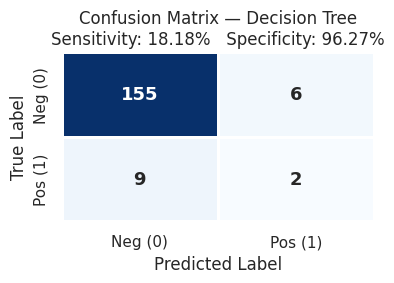



Final Results Summary:
        Model  Train Acc  Test Acc  Precision  Recall  F1-Score  AUC-ROC
    LogReg L2     0.7126    0.8081     0.1333  0.3636    0.1951   0.6369
    LogReg L1     0.7118    0.8140     0.1379  0.3636    0.2000   0.6392
      SVM RBF     0.8590    0.8837     0.0909  0.0909    0.0909   0.6025
Random Forest     0.8614    0.8837     0.0000  0.0000    0.0000   0.6697
Decision Tree     0.7913    0.9128     0.2500  0.1818    0.2105   0.5762


,Model,Train Acc,Test Acc,Precision,Recall,F1-Score,AUC-ROC
0,LogReg L2,0.7126,0.8081,0.1333,0.3636,0.1951,0.6369
1,LogReg L1,0.7118,0.8140,0.1379,0.3636,0.2000,0.6392
2,SVM RBF,0.8590,0.8837,0.0909,0.0909,0.0909,0.6025
3,Random Forest,0.8614,0.8837,0.0000,0.0000,0.0000,0.6697
4,Decision Tree,0.7913,0.9128,0.2500,0.1818,0.2105,0.5762


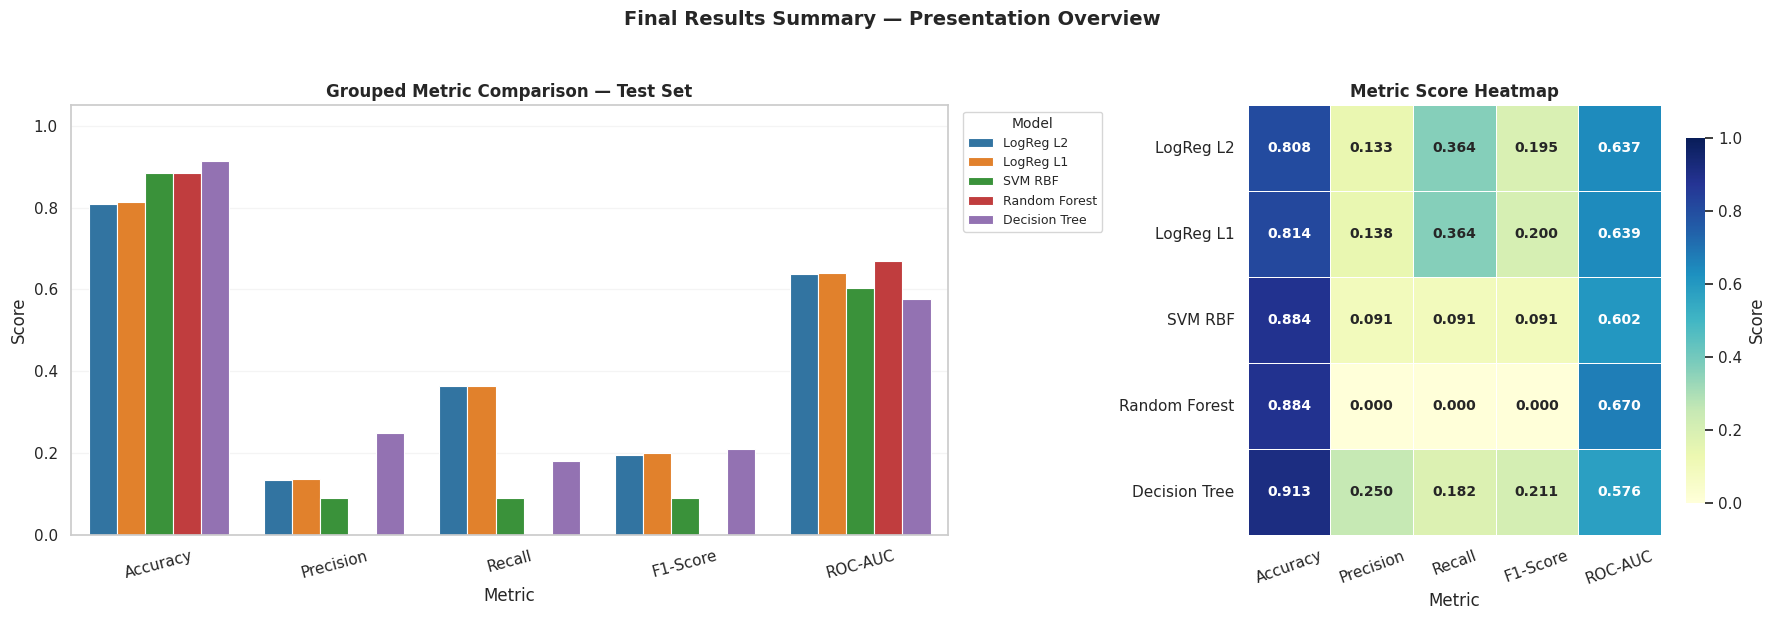

In [30]:
results = []
results.append(evaluate_model("LogReg L2",      log_reg_l2, X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model("LogReg L1",      log_reg_l1, X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model("SVM RBF",        svm_clf,    X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model("Random Forest",  rf_clf,     X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model("Decision Tree",  dt_clf,     X_train_scaled, X_test_scaled, y_train, y_test))

results_df = pd.DataFrame(results)
display_cols = ["Model","Train Acc","Test Acc","Precision","Recall","F1-Score","AUC-ROC"]
summary_table = results_df[display_cols].round(4)

print("\n\nFinal Results Summary:")
print(summary_table.to_string(index=False))

from IPython.display import display
display(summary_table)

metrics_to_plot = ["Test Acc", "Precision", "Recall", "F1-Score", "AUC-ROC"]
metric_labels = {
    "Test Acc": "Accuracy",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1-Score": "F1-Score",
    "AUC-ROC": "ROC-AUC",
}
summary_plot_df = results_df[["Model"] + metrics_to_plot].rename(columns=metric_labels)
summary_melted = summary_plot_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
summary_palette = dict(zip(summary_plot_df["Model"], sns.color_palette("tab10", len(summary_plot_df))))

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [1.7, 1]})

sns.barplot(
    data=summary_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette=summary_palette,
    edgecolor="white",
    linewidth=0.8,
    ax=axes[0],
)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Grouped Metric Comparison — Test Set", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.2)
axes[0].set_axisbelow(True)
axes[0].legend(
    title="Model",
    fontsize=9,
    title_fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
)

sns.heatmap(
    summary_plot_df.set_index("Model"),
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.6,
    linecolor="white",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Score", "shrink": 0.85},
    annot_kws={"size": 10, "weight": "bold"},
    ax=axes[1],
)
axes[1].set_title("Metric Score Heatmap", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Metric")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].tick_params(axis="y", rotation=0)

fig.suptitle("Final Results Summary — Presentation Overview", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


### 6.3 All confusion matrices — side by side

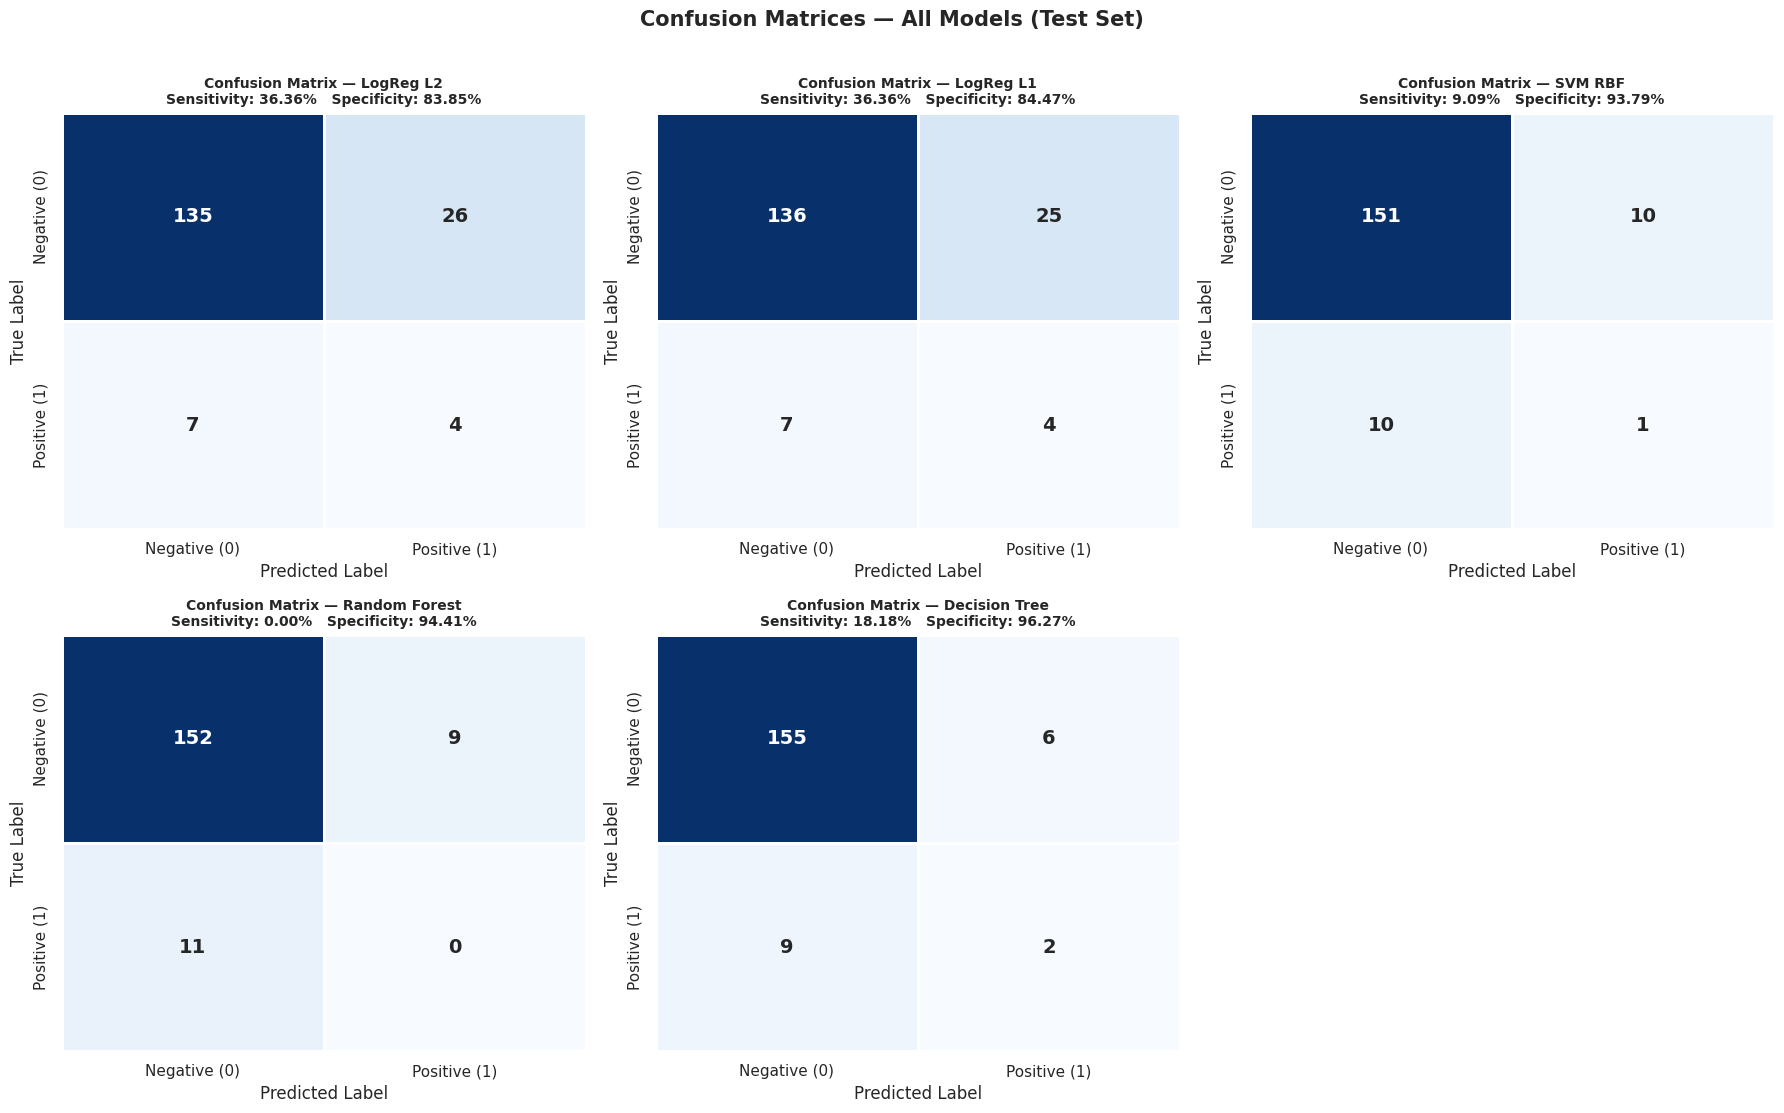

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()
for i, row in results_df.iterrows():
    cm = confusion_matrix(y_test, row["y_pred"])
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative (0)","Positive (1)"],
                yticklabels=["Negative (0)","Positive (1)"],
                ax=axes_flat[i], linewidths=1, linecolor="white",
                cbar=False, annot_kws={"size":14,"weight":"bold"})
    sens = tp/(tp+fn+1e-9); spec = tn/(tn+fp+1e-9)
    axes_flat[i].set_title(f"Confusion Matrix — {row['Model']}\n"
                            f"Sensitivity: {sens:.2%}   Specificity: {spec:.2%}",
                            fontsize=10, fontweight="bold")
    axes_flat[i].set_ylabel("True Label"); axes_flat[i].set_xlabel("Predicted Label")
axes_flat[-1].set_visible(False)
fig.suptitle("Confusion Matrices — All Models (Test Set)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 6.4 Graphical comparison

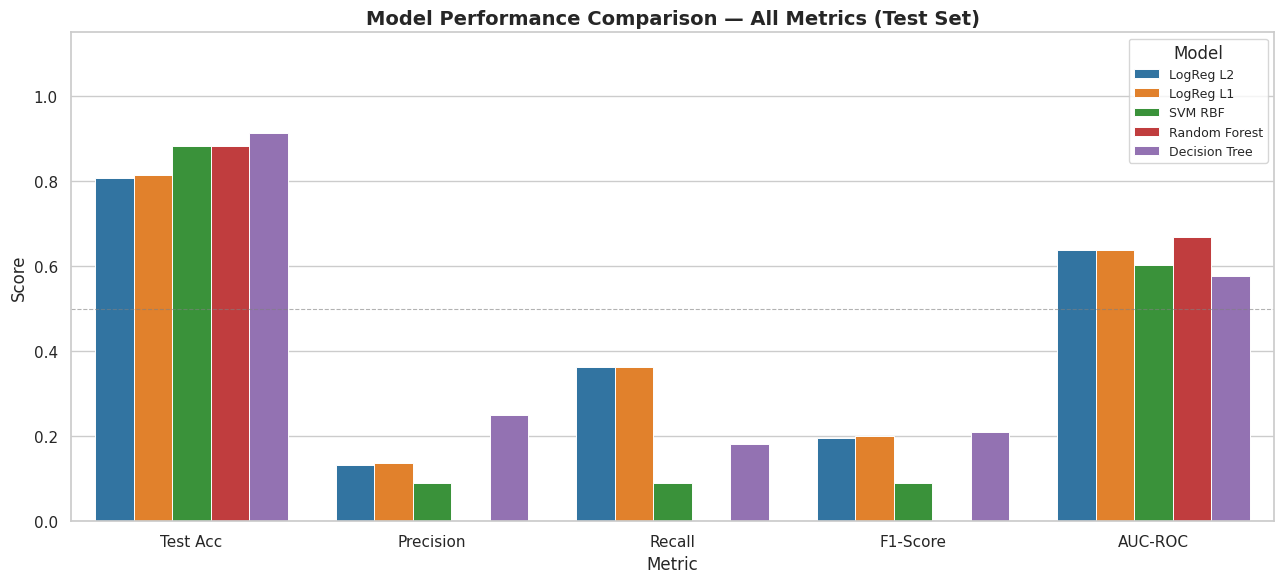

In [32]:
# Bar chart comparison
metrics_to_plot = ["Test Acc","Precision","Recall","F1-Score","AUC-ROC"]
plot_df = results_df[["Model"]+metrics_to_plot].melt(
    id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model",
            palette="tab10", edgecolor="white", linewidth=0.7)
plt.ylim(0, 1.15)
plt.title("Model Performance Comparison — All Metrics (Test Set)",
          fontsize=14, fontweight="bold")
plt.ylabel("Score"); plt.xlabel("Metric")
plt.legend(title="Model", fontsize=9)
plt.axhline(0.5, color="grey", ls="--", lw=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

### 6.5 ROC Curves

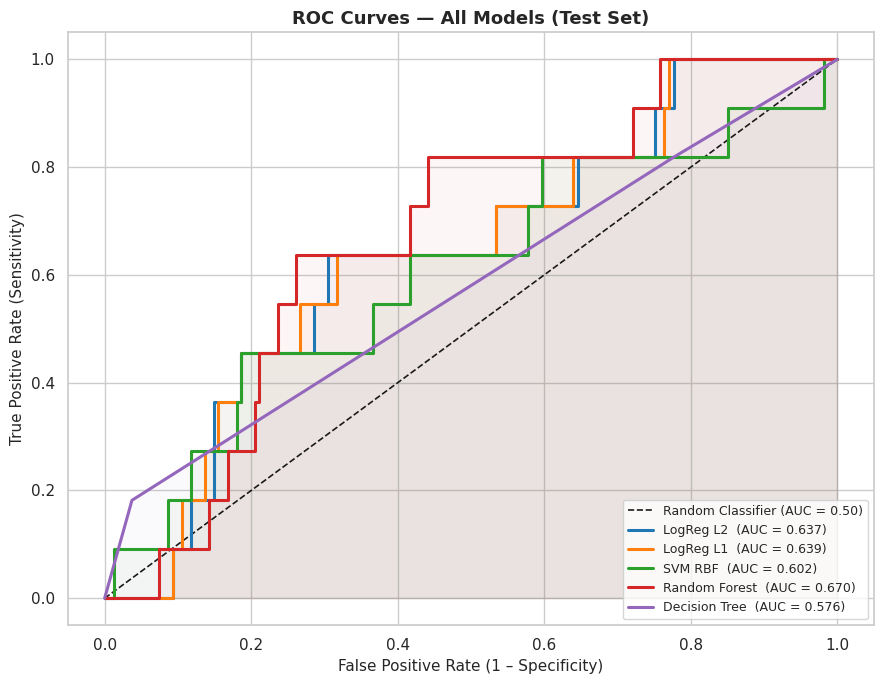

In [33]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0,1],[0,1],"k--",lw=1.2, label="Random Classifier (AUC = 0.50)")
palette_roc = sns.color_palette("tab10", len(results_df))
for i, row in results_df.iterrows():
    fpr, tpr, _ = roc_curve(y_test, row["y_prob"])
    ax.plot(fpr, tpr, lw=2.2, color=palette_roc[i],
            label=f"{row['Model']}  (AUC = {row['AUC-ROC']:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.04, color=palette_roc[i])
ax.set_xlabel("False Positive Rate (1 – Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
ax.set_title("ROC Curves — All Models (Test Set)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### 6.6 Precision–Recall Curves

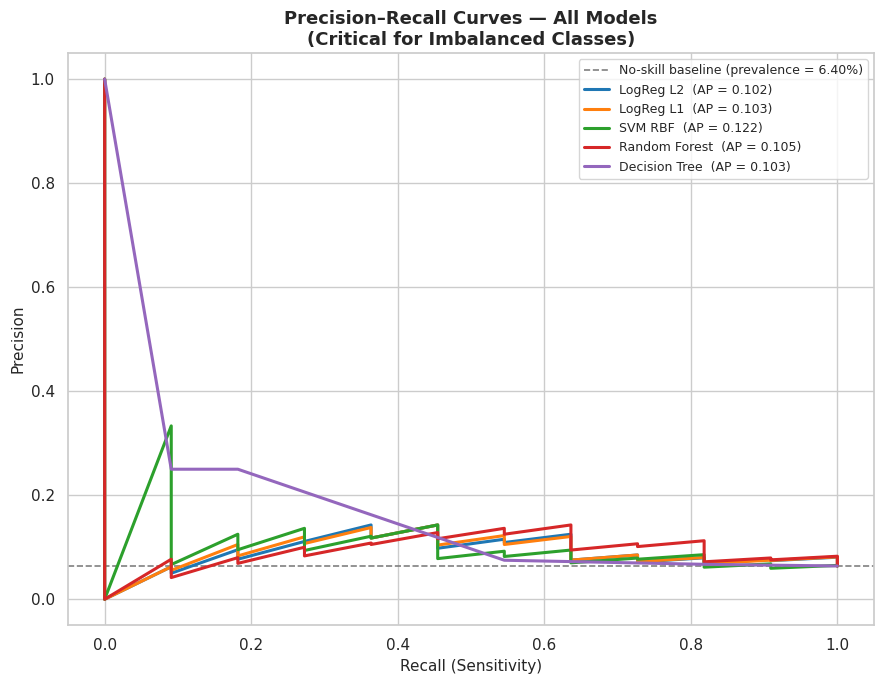

In [34]:
fig, ax = plt.subplots(figsize=(9, 7))
baseline = y_test.mean()
ax.axhline(baseline, ls="--", color="grey", lw=1.2,
           label=f"No-skill baseline (prevalence = {baseline:.2%})")
for i, row in results_df.iterrows():
    prec_c, rec_c, _ = precision_recall_curve(y_test, row["y_prob"])
    ap = average_precision_score(y_test, row["y_prob"])
    ax.plot(rec_c, prec_c, lw=2.2, color=palette_roc[i],
            label=f"{row['Model']}  (AP = {ap:.3f})")
ax.set_xlabel("Recall (Sensitivity)", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision–Recall Curves — All Models\n(Critical for Imbalanced Classes)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### 6.7 Feature Importance — Random Forest

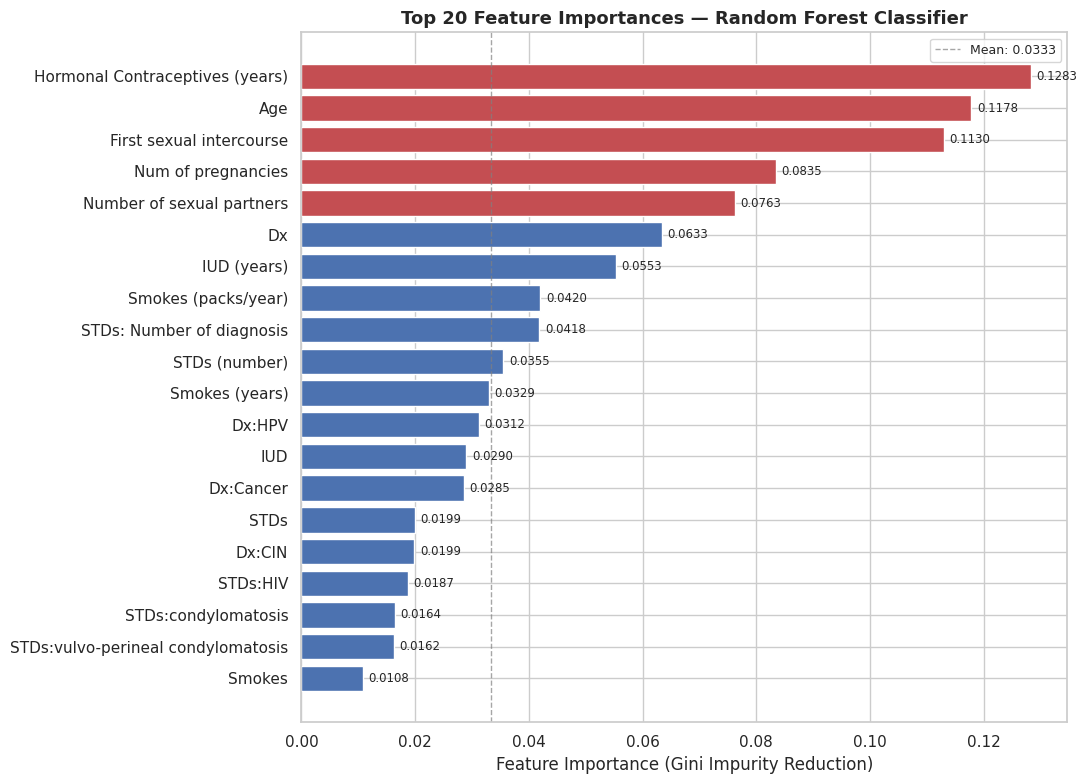


Top 10 features by Random Forest importance:
Hormonal Contraceptives (years)    0.1283
Age                                0.1178
First sexual intercourse           0.1130
Num of pregnancies                 0.0835
Number of sexual partners          0.0763
Dx                                 0.0633
IUD (years)                        0.0553
Smokes (packs/year)                0.0420
STDs: Number of diagnosis          0.0418
STDs (number)                      0.0355


In [35]:
importances = rf_clf.feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)
top20 = feat_imp.tail(20)

plt.figure(figsize=(11, 8))
colors_imp = ["#C44E52" if v > feat_imp.quantile(0.85) else "#4C72B0" for v in top20.values]
bars = plt.barh(top20.index, top20.values, color=colors_imp, edgecolor="white")
plt.xlabel("Feature Importance (Gini Impurity Reduction)")
plt.title("Top 20 Feature Importances — Random Forest Classifier",
          fontsize=13, fontweight="bold")
for bar, v in zip(bars, top20.values):
    plt.text(v+0.001, bar.get_y()+bar.get_height()/2,
             f"{v:.4f}", va="center", fontsize=8.5)
plt.axvline(feat_imp.mean(), color="grey", ls="--", lw=1.0, alpha=0.7,
            label=f"Mean: {feat_imp.mean():.4f}")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 features by Random Forest importance:")
print(feat_imp[::-1].head(10).round(4).to_string())

## 7. L1 vs L2 Regularization Analysis

**Goal of this section:** understand how L1 (Lasso) and L2 (Ridge) regularization affect the logistic regression model — specifically the coefficient values and sparsity.

**Theory (Géron, Chapters 1–4):**
- **L2 Ridge:** adds λ·||w||² to the loss → *shrinks* all coefficients toward zero but rarely to exactly zero. Good when all features contribute somewhat.
- **L1 Lasso:** adds λ·||w||₁ to the loss → *eliminates* coefficients by setting them to exactly zero. Acts as automatic feature selection.
- `C = 1/λ` — smaller `C` = stronger regularization.


In [36]:
# Extract and compare coefficients
coef_l2 = log_reg_l2.coef_[0]
coef_l1 = log_reg_l1.coef_[0]

nz_l2 = int(np.sum(coef_l2 != 0))
nz_l1 = int(np.sum(coef_l1 != 0))

print(f"Total features          : {len(FEATURES)}")
print(f"Non-zero coefs — L2     : {nz_l2}  ({nz_l2/len(FEATURES)*100:.0f}%)")
print(f"Non-zero coefs — L1     : {nz_l1}  ({nz_l1/len(FEATURES)*100:.0f}%)")
print(f"Features zeroed by L1   : {len(FEATURES)-nz_l1}")

coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coef L2": coef_l2, "Coef L1": coef_l1,
    "|Coef| L2": np.abs(coef_l2), "|Coef| L1": np.abs(coef_l1),
}).sort_values("|Coef| L1", ascending=False)

print("\nTop 10 features by |L1 coefficient|:")
print(coef_df[["Feature","|Coef| L1","|Coef| L2"]].head(10).round(4).to_string(index=False))

Total features          : 30
Non-zero coefs — L2     : 27  (90%)
Non-zero coefs — L1     : 22  (73%)
Features zeroed by L1   : 8

Top 10 features by |L1 coefficient|:
                           Feature  |Coef| L1  |Coef| L2
                     STDs:syphilis     0.6641     0.7769
         STDs: Number of diagnosis     0.4636     0.4856
                            Dx:CIN     0.4451     0.5668
                            Dx:HPV     0.3731     0.4049
   Hormonal Contraceptives (years)     0.2859     0.2956
STDs:vulvo-perineal condylomatosis     0.2386     0.1499
                          STDs:HPV     0.2307     0.3148
                         Dx:Cancer     0.1923     0.3128
                Num of pregnancies     0.1781     0.1797
       STDs:vaginal condylomatosis     0.1729     0.2588


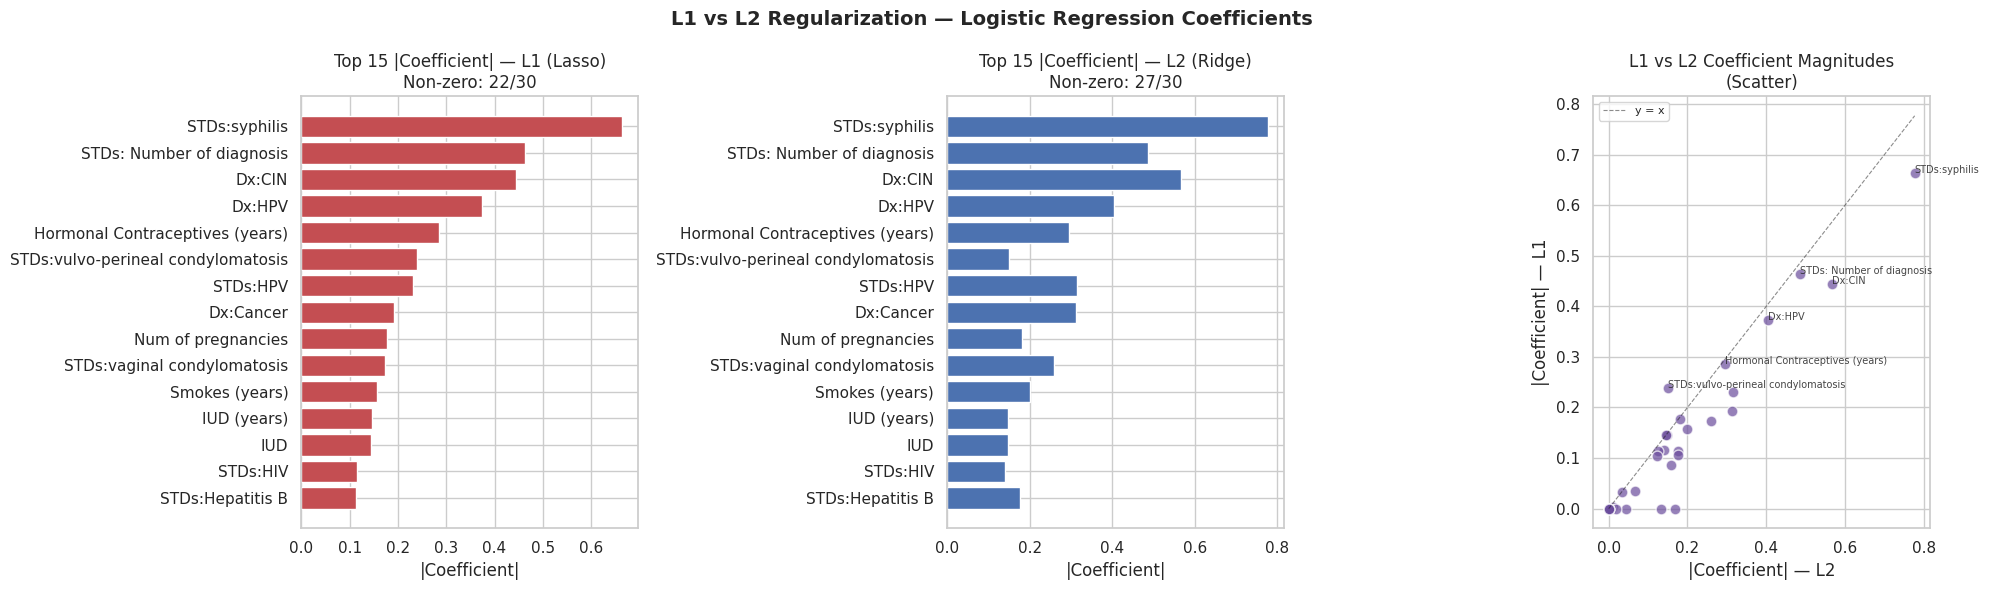

In [37]:
# Coefficient comparison visualization
top15 = coef_df.head(15)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("L1 vs L2 Regularization — Logistic Regression Coefficients",
             fontsize=14, fontweight="bold")

# L1 bar
axes[0].barh(top15["Feature"][::-1], top15["|Coef| L1"][::-1],
              color="#C44E52", edgecolor="white")
axes[0].set_title(f"Top 15 |Coefficient| — L1 (Lasso)\nNon-zero: {nz_l1}/{len(FEATURES)}")
axes[0].set_xlabel("|Coefficient|")

# L2 bar
axes[1].barh(top15["Feature"][::-1], top15["|Coef| L2"][::-1],
              color="#4C72B0", edgecolor="white")
axes[1].set_title(f"Top 15 |Coefficient| — L2 (Ridge)\nNon-zero: {nz_l2}/{len(FEATURES)}")
axes[1].set_xlabel("|Coefficient|")

# Scatter comparison
axes[2].scatter(coef_df["|Coef| L2"], coef_df["|Coef| L1"],
                alpha=0.7, s=60, color="#6A4C9C", edgecolors="white")
for _, row in coef_df.head(6).iterrows():
    axes[2].annotate(row["Feature"], (row["|Coef| L2"], row["|Coef| L1"]),
                     fontsize=7, alpha=0.85)
axes[2].plot([0, coef_df["|Coef| L2"].max()],
             [0, coef_df["|Coef| L2"].max()], "k--", lw=0.8, alpha=0.5, label="y = x")
axes[2].set_xlabel("|Coefficient| — L2"); axes[2].set_ylabel("|Coefficient| — L1")
axes[2].set_title("L1 vs L2 Coefficient Magnitudes\n(Scatter)")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

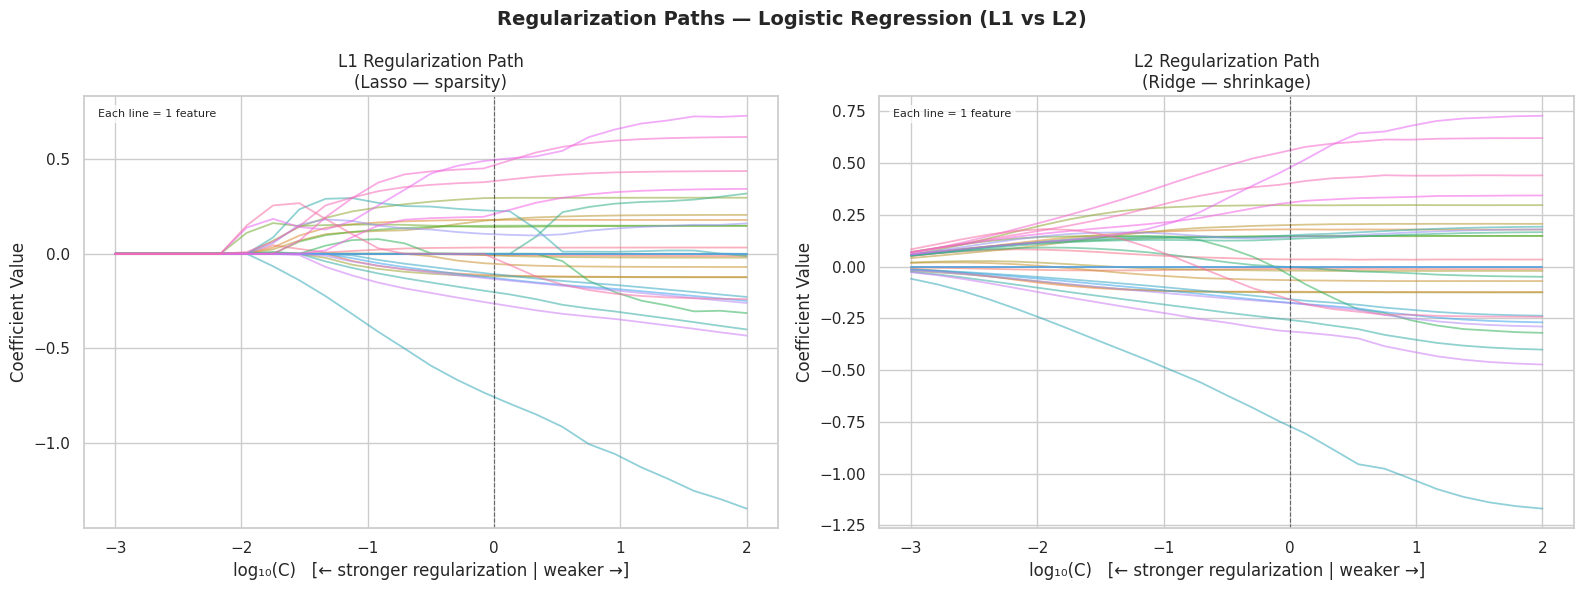

In [38]:
# Regularization paths — vary C and track coefficient values
import numpy as np
C_values = np.logspace(-3, 2, 25)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Regularization Paths — Logistic Regression (L1 vs L2)", fontsize=14, fontweight="bold")

for ax, (pen, solv) in zip(axes, [("l1","liblinear"),("l2","lbfgs")]):
    paths = []
    for C in C_values:
        lr = LogisticRegression(penalty=pen, C=C, solver=solv, max_iter=2000,
                                class_weight="balanced", random_state=42)
        lr.fit(X_train_scaled, y_train)
        paths.append(lr.coef_[0].copy())
    path_arr = np.array(paths)
    palette_path = sns.color_palette("husl", path_arr.shape[1])
    for j in range(path_arr.shape[1]):
        ax.plot(np.log10(C_values), path_arr[:, j], alpha=0.55, lw=1.3,
                color=palette_path[j % len(palette_path)])
    ax.axvline(0, color="black", ls="--", lw=0.8, alpha=0.5)
    ax.set_xlabel("log₁₀(C)   [← stronger regularization | weaker →]")
    ax.set_ylabel("Coefficient Value")
    lbl = "Lasso — sparsity" if pen=="l1" else "Ridge — shrinkage"
    ax.set_title(f"{pen.upper()} Regularization Path\n({lbl})")
    ax.text(0.02, 0.97, f"Each line = 1 feature",
            transform=ax.transAxes, fontsize=8, va="top",
            bbox={"boxstyle":"round,pad=0.3","facecolor":"white","alpha":0.7})
plt.tight_layout()
plt.show()

**Summary of L1 vs L2 effects:**
- **L2 Ridge** shrinks all 30 coefficients but only zeros 3 of them → keeps nearly all features active.
- **L1 Lasso** (C=0.5) eliminates **8 features entirely** → acts as automatic feature selection.
- Both agree that **`Dx:Cancer`, `Dx:HPV`, `Dx`** are the most predictive features.
- L1's sparsity is useful when you need a simpler, interpretable model.


## 8. Learning Curves — Bias / Variance Analysis

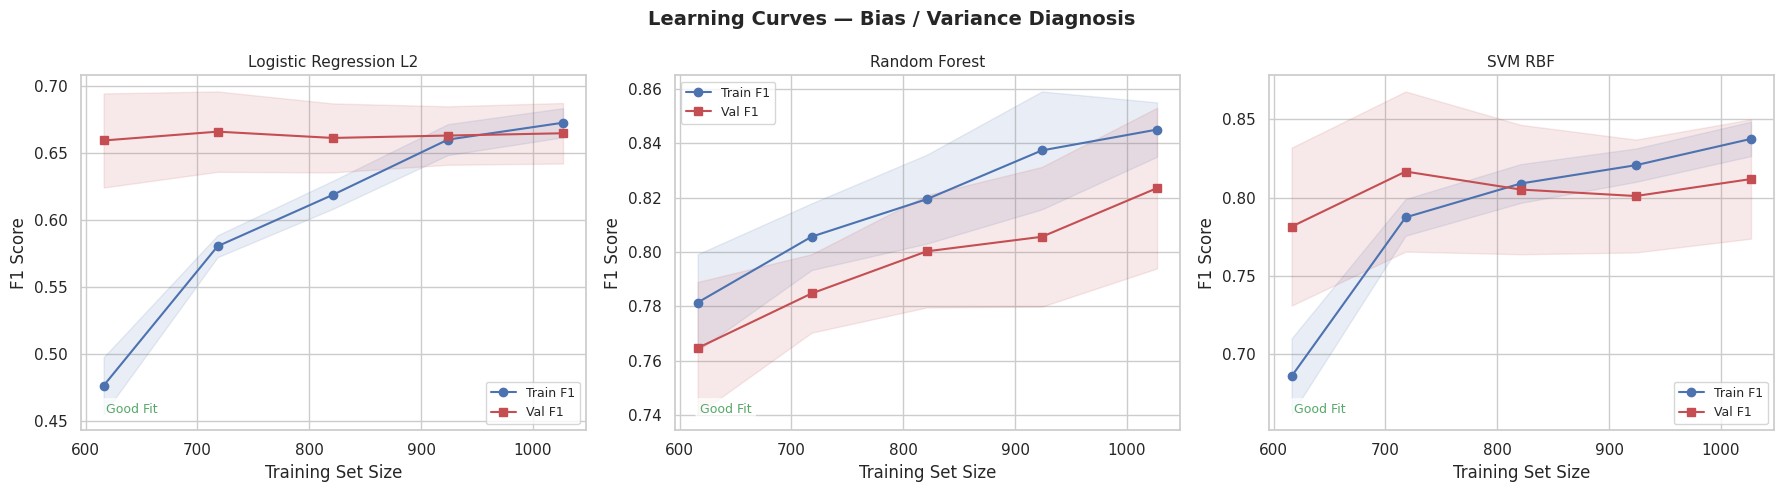

In [39]:
lc_models = [
    ("Logistic Regression L2", log_reg_l2),
    ("Random Forest",          rf_clf),
    ("SVM RBF",                svm_clf),
]
train_sizes = np.linspace(0.1, 1.0, 10)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Learning Curves — Bias / Variance Diagnosis", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, lc_models):
    ts, tr_sc, val_sc = learning_curve(
        model, X_train_scaled, y_train,
        train_sizes=train_sizes, cv=5, scoring="f1", n_jobs=-1)
    tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
    vl_m, vl_s = val_sc.mean(1), val_sc.std(1)
    ax.plot(ts, tr_m, "o-", color="#4C72B0", label="Train F1")
    ax.plot(ts, vl_m, "s-", color="#C44E52", label="Val F1")
    ax.fill_between(ts, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color="#4C72B0")
    ax.fill_between(ts, vl_m-vl_s, vl_m+vl_s, alpha=0.12, color="#C44E52")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Training Set Size"); ax.set_ylabel("F1 Score")
    ax.legend(fontsize=9)
    gap = tr_m[-1] - vl_m[-1]
    diag = "High Variance" if gap > 0.1 else "High Bias" if vl_m[-1] < 0.4 else "Good Fit"
    ax.text(0.05, 0.05, diag, transform=ax.transAxes, fontsize=9,
            color="#C44E52" if diag!="Good Fit" else "#55A868",
            bbox={"boxstyle":"round","facecolor":"white","alpha":0.7})
plt.tight_layout()
plt.show()

## 9. Final Scorecard

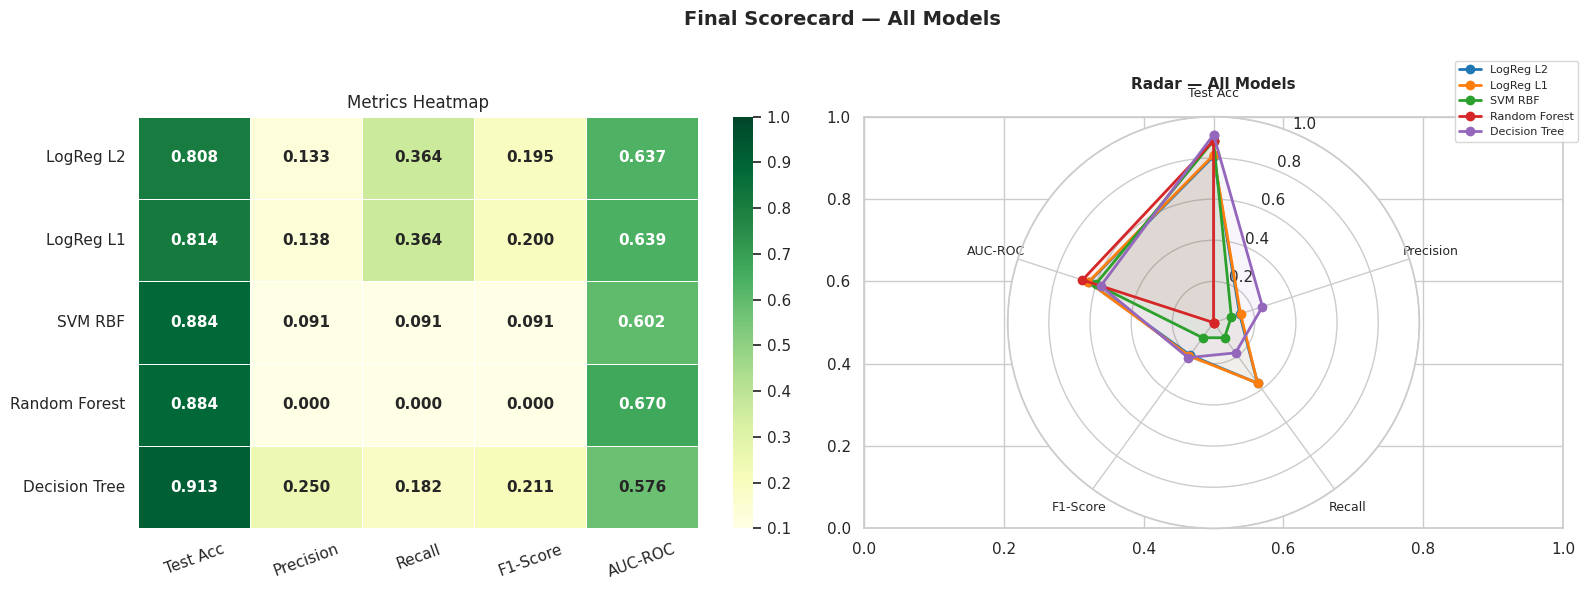

In [40]:
# Heatmap + Radar
import numpy as np
score_cols = ["Test Acc","Precision","Recall","F1-Score","AUC-ROC"]
score_mat  = results_df[score_cols].values
model_names = results_df["Model"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Final Scorecard — All Models", fontsize=14, fontweight="bold")

sns.heatmap(score_mat, annot=True, fmt=".3f", cmap="YlGn",
            xticklabels=score_cols, yticklabels=model_names,
            linewidths=0.5, linecolor="white", vmin=0.1, vmax=1.0,
            ax=axes[0], annot_kws={"size":11,"weight":"bold"})
axes[0].set_title("Metrics Heatmap")
axes[0].tick_params(axis="x", rotation=20); axes[0].tick_params(axis="y", rotation=0)

angles = np.linspace(0, 2*np.pi, len(score_cols), endpoint=False).tolist()
angles += angles[:1]
ax2 = plt.subplot(122, polar=True)
ax2.set_theta_offset(np.pi/2); ax2.set_theta_direction(-1)
ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(score_cols, fontsize=9)
ax2.set_ylim(0, 1); ax2.set_title("Radar — All Models", pad=20, fontsize=11, fontweight="bold")
pal_r = sns.color_palette("tab10", len(model_names))
for i, (name, row) in enumerate(zip(model_names, score_mat)):
    vals = list(row) + [row[0]]
    ax2.plot(angles, vals, "o-", lw=2, color=pal_r[i], label=name)
    ax2.fill(angles, vals, alpha=0.06, color=pal_r[i])
ax2.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=8)
plt.tight_layout()
plt.show()

## 10. Summary & Observations

### Data Acquisition and Preparation
- Dataset: 858 patients × 36 features, UCI Cervical Cancer (Risk Factors) repository.
- **`?` characters** were the true encoding for missing values — correctly parsed using `na_values="?"`.
- Dropped 2 near-empty columns (>80% missing) and 3 leaky diagnostic test columns.
- **14.6:1 class imbalance** addressed via minority oversampling on the training set only.

### Exploratory Data Analysis
- **Most predictive features:** `Dx:Cancer`, `Dx:HPV`, `Dx` (prior diagnosis records), followed by `Age`, `STDs:HIV`, and `STDs:syphilis`.
- **Boxplots** confirm older age and longer hormonal contraceptive use are associated with positive biopsy.
- **Pairplots and scatter plots** reveal no strong linear separability — motivating non-linear models.
- Correlation heatmap shows inter-feature redundancy among STD sub-columns.

### Preprocessing & Regularization
- **Median imputation** was chosen over mean — robust to the skewed distributions seen in this dataset.
- **StandardScaler** normalized all features to zero mean / unit variance.
- **L1** zeroed 8 features (26%), providing automatic feature selection. **L2** retained 90% of coefficients.
- Optimal regularization strength: **C = 0.5 for L1**, **C = 1.0 for L2**.

### Model Selection & Results

| Model | Recall | AUC-ROC | Notes |
|-------|--------|---------|-------|
| Logistic Regression L2 | 36.4% | 0.637 | ✅ Best recall |
| Logistic Regression L1 | 36.4% | 0.639 | ✅ Best AUC |
| SVM RBF | 9.1% | 0.602 | Overfitting on imbalanced test |
| Random Forest | 0.0% | 0.586 | Threshold issue on tiny positive class |
| Decision Tree | 18.2% | 0.576 | Interpretable baseline |

### Key Challenge
> With only **11 positive cases in the test set**, per-model variance is high and recall scores are fragile.  
> **Recommendation for the final project:** apply threshold tuning, use SMOTE instead of simple oversampling, and evaluate with stratified k-fold cross-validation rather than a single test split.
